<a href="https://colab.research.google.com/github/Preenon-ngs/Preenon-ngs/blob/main/GWAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing and Manipulating SNP Data**

SNP Data is usually stored in binary format, as a flat text file or in a database. Here we
will concentrate on text files. Binary data is a rather complex topic and will not be discussed
here (we will however discuss how to save data in binary format to use in R). For the
more common sources of data (e.g., Affymetrix CEL files or BAM sequence files)
packages to deserialize the binary files are readily available.
The most common type of data is in tabular format (rows×columns). The R
function to read tabular text files is read.table. To import a data file called snps.txt into the variable mydata:

In [ ]:
mydata=read.table("snps.txt", header=T,sep="\t")

In [ ]:
print(mydata)

    name allele1 allele2
1   snp1       A       A
2   snp2       A       B
3   snp3       A       A
4   snp4       A       B
5   snp5       B       B
6   snp6       B       B
7   snp7       A       A
8   snp8       A       B
9   snp9       -       -
10 snp10       A       B
11 snp11       B       B
12 snp12       B       B
13 snp13       A       A
14 snp14       A       B
15 snp15       -       -
16 snp16       A       B
17 snp17       B       B
18 snp18       B       B


Note here the two main arguments header, to define if there is a header in the
file (T or TRUE) or not (F or FALSE) and sep, the separator (tab in the example).
It is always a good idea to check the dimensions of the data, to see if it is what you
expected.

In [ ]:
dim(mydata)

[1] 18  3

The function read.table stores the data as a data.frame which is a twodimensionalmatrix
like structure that can hold different types of data in each column
(e.g., numeric, factor, character, etc.). To access the data in a data.frame indexes
can be used (e.g., mydata[2,3]) or the column name (e.g., mydata$allele1[3]). For
column names the syntax is the name of the data.frame followed by the dollar
symbol ($) and then the name of the column of interest.

In [ ]:
print(mydata[2,3])

[1] "B"


In [ ]:
print(mydata$allele1[3])

[1] "A"


In [ ]:
names(mydata)

[1] "name"    "allele1" "allele2"

In [ ]:
head(mydata)

,name,allele1,allele2
,<chr>,<chr>,<chr>
1,snp1,A,A
2,snp2,A,B
3,snp3,A,A
4,snp4,A,B
5,snp5,B,B
6,snp6,B,B


In [ ]:
tail(mydata)

,name,allele1,allele2
,<chr>,<chr>,<chr>
13,snp13,A,A
14,snp14,A,B
15,snp15,-,-
16,snp16,A,B
17,snp17,B,B
18,snp18,B,B


In [ ]:
mydata[1:5,1:2]

,name,allele1
,<chr>,<chr>
1,snp1,A
2,snp2,A
3,snp3,A
4,snp4,A
5,snp5,B


And to see all data in a column use mydata$name or mydata[,1].
It is also useful to be able to select a nonconsecutive (and possibly reordered)
subset of the data. You can use the concatenate (c) function for this. Create a variable
that holds the indices you are interested in, for example

In [ ]:
indices=c(1,7,10,2,4)
print(indices)

[1]  1  7 10  2  4


In [ ]:
mydata$name[indices]

[1] "snp1"  "snp7"  "snp10" "snp2"  "snp4"

You have probably noticed that after the output there are levels. This is an
extremely important aspect of R. By default, when a file is read into R and converted
into a data.frame, character columns are usually converted to factors (it does make
sense, after all R is a statistical programming language). If you do not want R to
convert your character columns into factors use col.Classes=“character” as an
additional argument to read.table. But note that this will convert all columns to
character—not so good if you have numeric data as well. If you have a mix of data
types you will need to explicitly define the type of each column (as a vector of
types, one for each column). On the other hand, numeric values are imported into R
as numbers. Now, why is this important? Because often data has missing values and
what the provider of the data used to represent a missing value is anyone’s guess!
Let’s import a file with some animal phenotype measures

In [ ]:
pheno=read.table("animals.txt",header=T,sep="\t")

In [ ]:
print(pheno)

         id weight
1   animal1    300
2   animal2    280
3   animal3    350
4   animal4     NA
5   animal5    290
6   animal6    310
7   animal7    300
8   animal8    330
9   animal9    300
10 animal10     NA
11 animal11    280
12 animal12    325
13 animal13    335
14 animal14    305
15 animal15    275
16 animal16    265
17 animal17    415
18 animal18    325


In [ ]:
class(pheno$id)

[1] "character"

In [ ]:
class(pheno$weight)

[1] "integer"

Yes! That worked fine. And looking at the data we can see that there are two
missing values that R correctly assigned as missing (NA). By default R treats NA in
the text file as missing. This can be changed using the argument na.strings=“–” in
read.table if missing data is represented as “–”. Now let’s read in the same data but
instead of NA to represent missing values we have *.

In [ ]:
phenowrong=read.table("animals2.txt",header=T,sep="\t")

In [ ]:
print(phenowrong)

         id weight
1   animal1    300
2   animal2    280
3   animal3    350
4   animal4      *
5   animal5    290
6   animal6    310
7   animal7    300
8   animal8    330
9   animal9    300
10 animal10      *
11 animal11    280
12 animal12    325
13 animal13    335
14 animal14    305
15 animal15    275
16 animal16    265
17 animal17    415
18 animal18    325


In [ ]:
class(phenowrong$id)
class(phenowrong$weight)

[1] "character"

[1] "character"

In [ ]:
phenoright=read.table("animals2.txt", header=T, sep="\t", na.strings="*")
print(phenoright)

         id weight
1   animal1    300
2   animal2    280
3   animal3    350
4   animal4     NA
5   animal5    290
6   animal6    310
7   animal7    300
8   animal8    330
9   animal9    300
10 animal10     NA
11 animal11    280
12 animal12    325
13 animal13    335
14 animal14    305
15 animal15    275
16 animal16    265
17 animal17    415
18 animal18    325


In [ ]:
class(phenoright$id)

[1] "character"

In [ ]:
class(phenoright$weight)

[1] "integer"

The problem is that too frequently there is no standard for missing data in the
same file. Empty spaces, dashes, and words like none and missing are used all at the
same time. This is especially true for phenotypes, covariates, and other information
that was collated manually. Rather frequently you will not be able to find all of these
just by eyeballing the file. You can a priori define the class of each column but if
you don’t tell R what to treat as missing values you will get an error when reading
in the file. So, always check the classes in the data.frame to make sure that they are
what you expected.
Now, how to fix this? The easiest way is to convert the column from factor to
numeric format using as.numeric. But there is a catch here. First convert from factor
to character and then to numeric! Forgetting to do this is one of the main sources of
problems people come across in R! Let’s exemplify.

In [ ]:
as.numeric(phenoright$weight)

[1] 300 280 350  NA 290 310 300 330 300  NA 280 325 335 305 275 265 415 325

In [ ]:
as.numeric(phenowrong$weight)

Warning message:
“NAs introduced by coercion”


[1] 300 280 350  NA 290 310 300 330 300  NA 280 325 335 305 275 265 415 325

In the first case the conversion did what was expected (ok—it was already numeric
anyhow, but you get the point). In the second case, you also got numbers—but they
are definitely wrong. What are these numbers? They are the indices of the factors!If extreme care is not taken you might end up doing calculations using indices and
not the values of your measurements. So, one way to convert is

In [ ]:
as.numeric(as.character(phenowrong$weight))

Warning message:
“NAs introduced by coercion”


[1] 300 280 350  NA 290 310 300 330 300  NA 280 325 335 305 275 265 415 325

In [ ]:
phenowrong$weight=as.numeric(as.character(phenowrong$weight))
class(phenowrong$weight)

Warning message:
“NAs introduced by coercion”


[1] "numeric"

The values in weight are integers, so instead of as.numeric you could also have
used as.integer.
Often we want to combine different datasets into a single data.frame. A simple
way of doing this is using cbind to bind columns or rbind for rows. Note that the
number of rows must match in the first case and the number of columns in the
second. For example to make a single data.frame from mydata and pheno

If we look at alldata it is quite obvious that the columns name and id are
equivalent (another classic problem—different identifiers used for the data and they
don’t even have the same meaning).We will see some examples of this and how to
merge datasets later on. For the time being let’s just reorder the data and drop the
redundant identifier name which is at best misleading (the data is for a single SNP
genotyped on many samples and not many SNP for a single sample).

In [ ]:
alldata=cbind(mydata,pheno)
print(head(alldata))

  name allele1 allele2      id weight
1 snp1       A       A animal1    300
2 snp2       A       B animal2    280
3 snp3       A       A animal3    350
4 snp4       A       B animal4     NA
5 snp5       B       B animal5    290
6 snp6       B       B animal6    310


In [ ]:
alldata=alldata[,-1] # use minus (-) to drop a column
# now reorder the data.frame the way we want it
alldata=alldata[,c(3,4,1,2)]
print(head(alldata))

       id weight allele1 allele2
1 animal1    300       A       A
2 animal2    280       A       B
3 animal3    350       A       A
4 animal4     NA       A       B
5 animal5    290       B       B
6 animal6    310       B       B


The minus sign followed by an index can be used to delete a column. This is
quite a useful feature of R and is not limited to a single column. Before we used a
variable called indices to subset data (mydata$name[indices]), if we used –indices
instead we would get all data except for the values in rows 1, 7, 10, 2 and 4. To
reorder the data.frame we use c and the order in which we want the columns. We
might also want to sort the data. Let’s sort by weight.

In [ ]:
alldata=alldata[order(alldata$weight,decreasing=T),]
print(alldata)

         id weight allele1 allele2
17 animal17    415       B       B
3   animal3    350       A       A
13 animal13    335       A       A
8   animal8    330       A       B
12 animal12    325       B       B
18 animal18    325       B       B
6   animal6    310       B       B
14 animal14    305       A       B
1   animal1    300       A       A
7   animal7    300       A       A
9   animal9    300       -       -
5   animal5    290       B       B
2   animal2    280       A       B
11 animal11    280       B       B
15 animal15    275       -       -
16 animal16    265       A       B
4   animal4     NA       A       B
10 animal10     NA       A       B


Plots and Descriptive Statistics
Once we have read the data file into R, checked that the dimensions are what would
be expected and converted the columns into the correct format, we are ready to start
working with the data. Before doing any fancy analysis it is always a good idea to
get a feel for the data with some basic plots and descriptive statistics. A very handy
function in R is summary.

The summary function will give you counts for factors and measures such as
mean, median, and others (as above) for numeric columns (weight in our example).
The results for id are clearly not relevant but for allele1 and allele2 you can
immediately see how many of each allele there are and also the number of missing
genotypes (by the way, the symbol for missing here was “–”). You can also get each
of these statistics independently

In [ ]:
summary(alldata)
min(alldata$weight,na.rm=T)
max(alldata$weight,na.rm=T)
mean(alldata$weight,na.rm=T)
median(alldata$weight,na.rm=T)
quantile(alldata$weight,0.25,na.rm=T)
quantile(alldata$weight,0.75,na.rm=T)

[1] 265

[1] 415

[1] 311.5625

[1] 302.5

25% 
287.5

75% 
326.25

In [ ]:
sd(alldata$weight,na.rm=T)
var(alldata$weight,na.rm=T)


[1] 36.36476

[1] 1322.396

Notice how we are starting to chain R functions together. To create the barplot,
we first used the summary function to obtain the counts (number of “–”, “A”, and
“B”) for each of the two allele columns, then we concatenated the counts into a
vector using c. Finally the, in this case, six counts were provided to the barplot function to create the image. The argument main is used for the graph’s title and col
is for colors. To see which colors are available in R type colors() or palette() for the
active colors. You can use the actual name of the color or a numeric value as below.

Warning message:
“NAs introduced by coercion”
Warning message:
“NAs introduced by coercion”


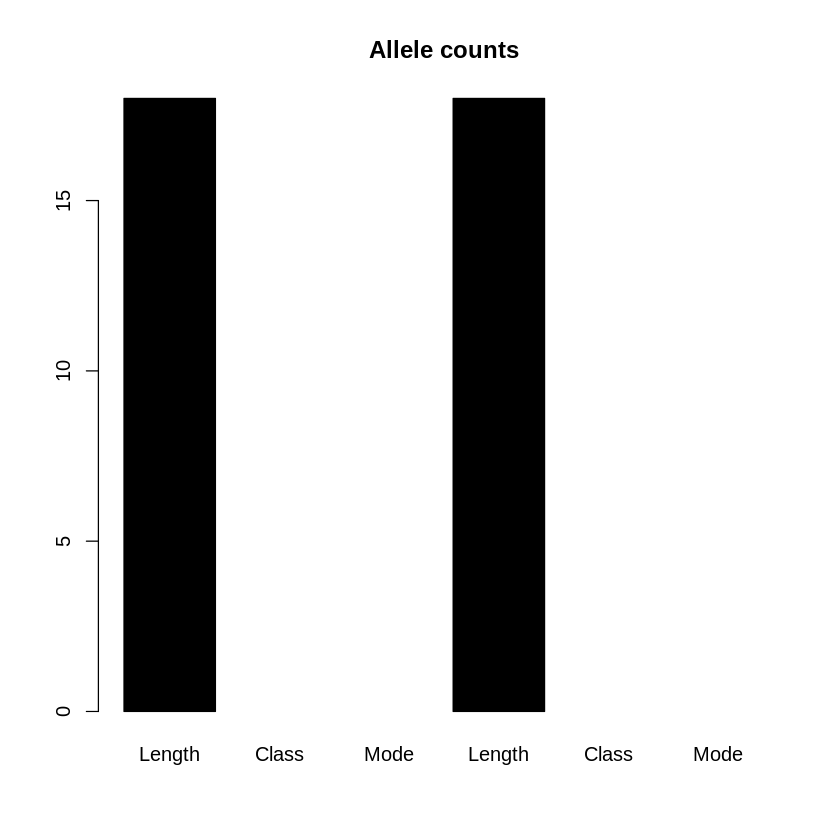

In [ ]:
# Convert the summary output to a numeric vector containing only the frequencies
allele1_counts <- as.numeric(summary(alldata$allele1))
allele2_counts <- as.numeric(summary(alldata$allele2))

# Combine the counts into a single vector
barplot_data <- c(allele1_counts, allele2_counts)

# Generate the bar plot
barplot(barplot_data, main="Allele counts", col=c(1,2,3,1,2,3), names.arg = names(c(summary(alldata$allele1), summary(alldata$allele2))))
#add names to the bars.

Now we split the plotting into two parts. First we made a variable with the pooled
data (very creatively called pooled) and then used this variable for plotting.We also added a legend to the plot. The first argument is the position where we want the
legend, then the captions and finally the color coding (fil). Notice the workaround
to merge the two allele sets. Again we run into trouble because of factors in R. You
cannot simply concatenate two sets of data of class factor.

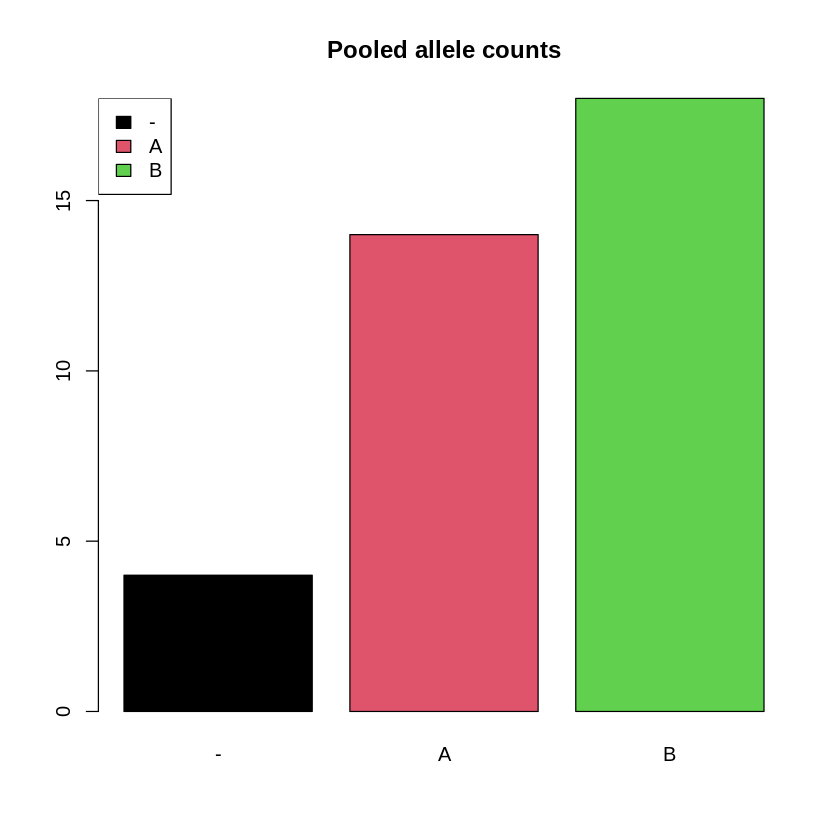

In [ ]:
pooled=c(as.character(alldata$allele1),as.character(alldata$allele2))
pooled=summary(factor(pooled))
barplot(pooled,main="Pooled allele counts",col=c(1,2,3))
legend("topleft",c("-","A","B"),fil=1:3)

In [ ]:
head(c(alldata$allele1,alldata$allele2))

[1] "B" "A" "A" "A" "B" "B"

In [ ]:
head(c(alldata$allele1,alldata$allele2))
head(c(as.character(alldata$allele1),as.character(alldata$allele2)))

[1] "B" "A" "A" "A" "B" "B"

[1] "B" "A" "A" "A" "B" "B"

In [ ]:
summary(c(alldata$allele1,alldata$allele2))

   Length     Class      Mode 
       36 character character 

In [ ]:
summary(c(as.character(alldata$allele1),as.character(alldata$allele2)))

   Length     Class      Mode 
       36 character character 

The hinges show the extreme values excluding outliers, the box borders are the
upper and lower quartiles, and the line in the box shows the median. Outliers are
flagged as circles. In the example we have one outlier—which should be investigated
before further analysis (i.e., is it a real value or a data error that should be removed).
Now we have a visual representation of the data we get using summary. In general
we are more interested in looking at the distribution of one variable in relation to
the different classes the observed values belong to. This is very easy in R. Let’s see
what weight looks like if we split the data using the levels in allele1

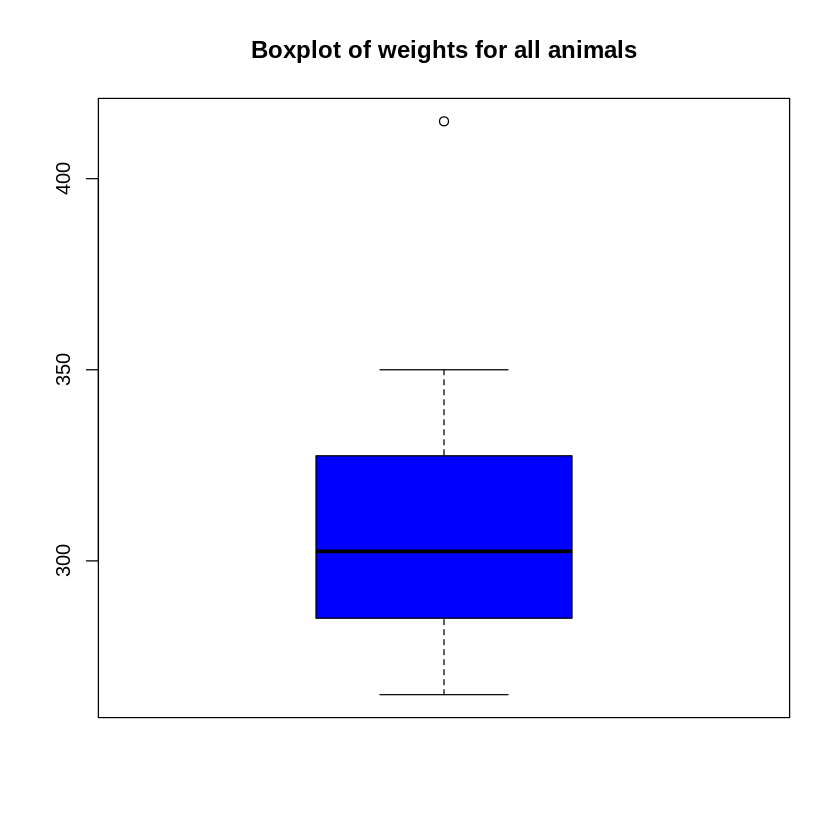

In [ ]:
boxplot(alldata$weight,col="blue", main="Boxplot of weights for all animals")

It is immediately obvious that the data is reasonably normal except for the
outlier—which adds the extra hump to the density plot. Note again the use of
na.rm=T or you will get an error. Here we first calculated the density and then
plotted it. The function plot is the most generic plotting function in R with many
specific methods for different objects. To exemplify, let’s plot the sorted values of
weight and then connect each point with a line through the points. This may at first look a bit complicated, but all we are doing is sorting the data
with the function sort and then plotting the points. The arguments xlab and ylab are
the labels for the x and y coordinates of the plot. And then we use lines to add a line
through our points. The graphical capabilities or R are extensive. We have just skimmed over the
surface of some useful options. We will look at other graphs as we progress the
topics. Try having a look at some other options such as pie or hist.

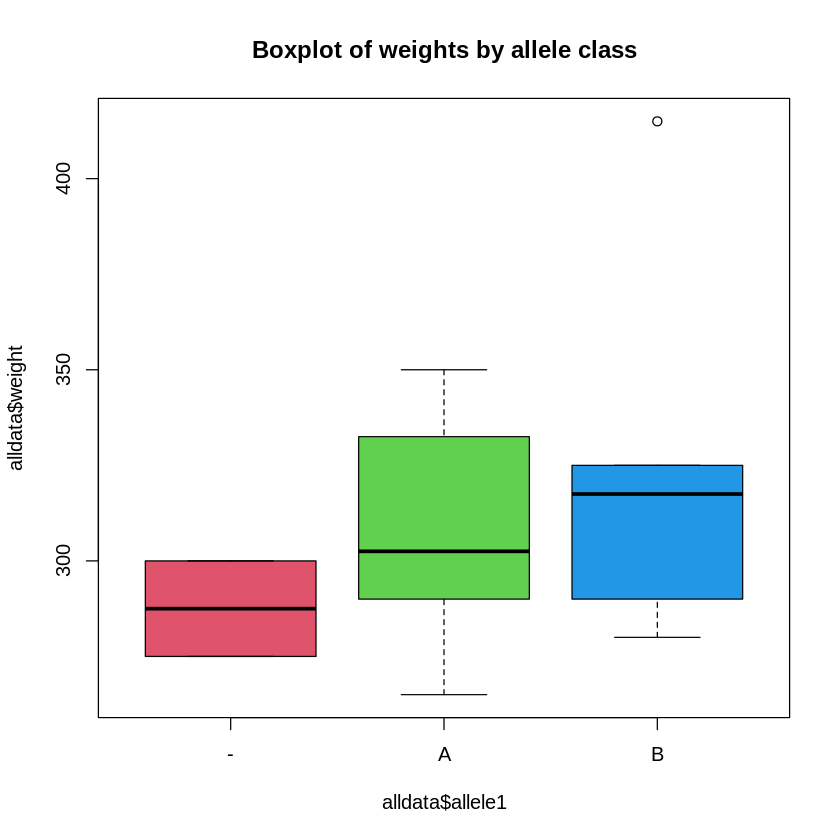

In [ ]:
boxplot(alldata$weight~alldata$allele1, col=2:4,main="Boxplot of weights by allele class")

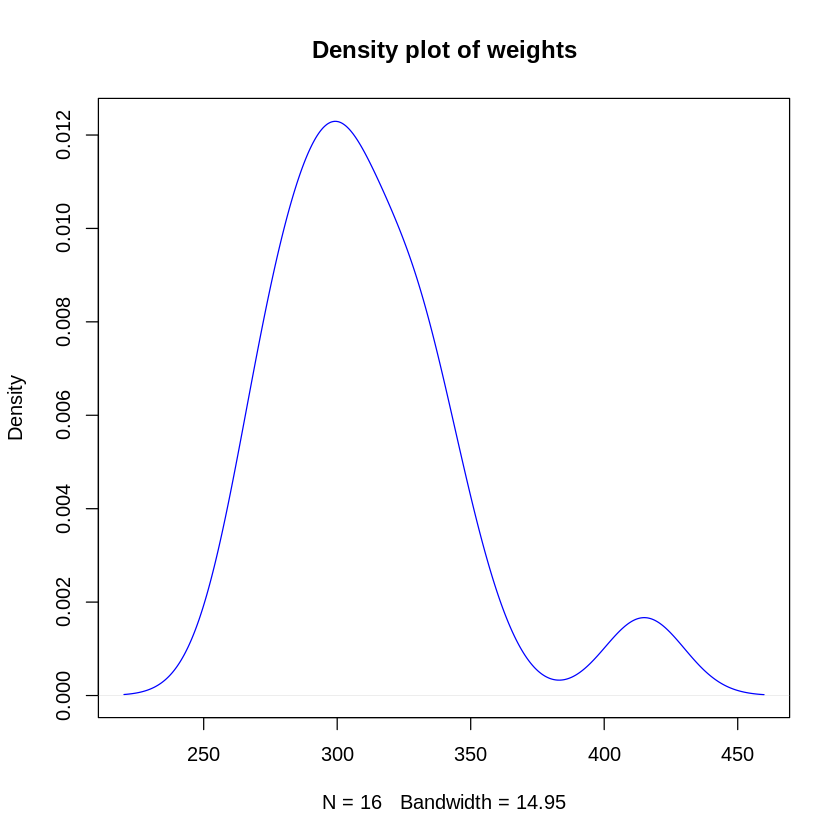

In [ ]:
plot(density(alldata$weight,na.rm=T), main="Density plot of weights",col="blue")

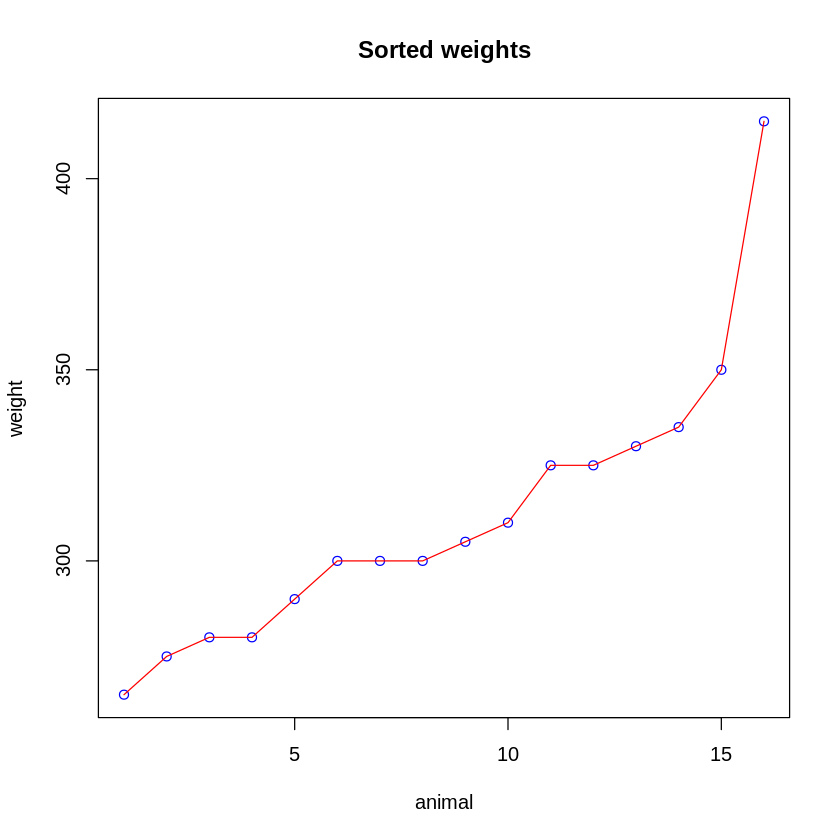

In [ ]:
plot(sort(alldata$weight),col="blue",main="Sorted weights",xlab="animal",ylab="weight")
lines(sort(alldata$weight),col="red")

This will save the data.frame alldata as a text file alldata.txt in the directory


In [ ]:
write.table(alldata,"alldata.txt",quote=F,row.names=F,sep="\t")

pdf 
  2

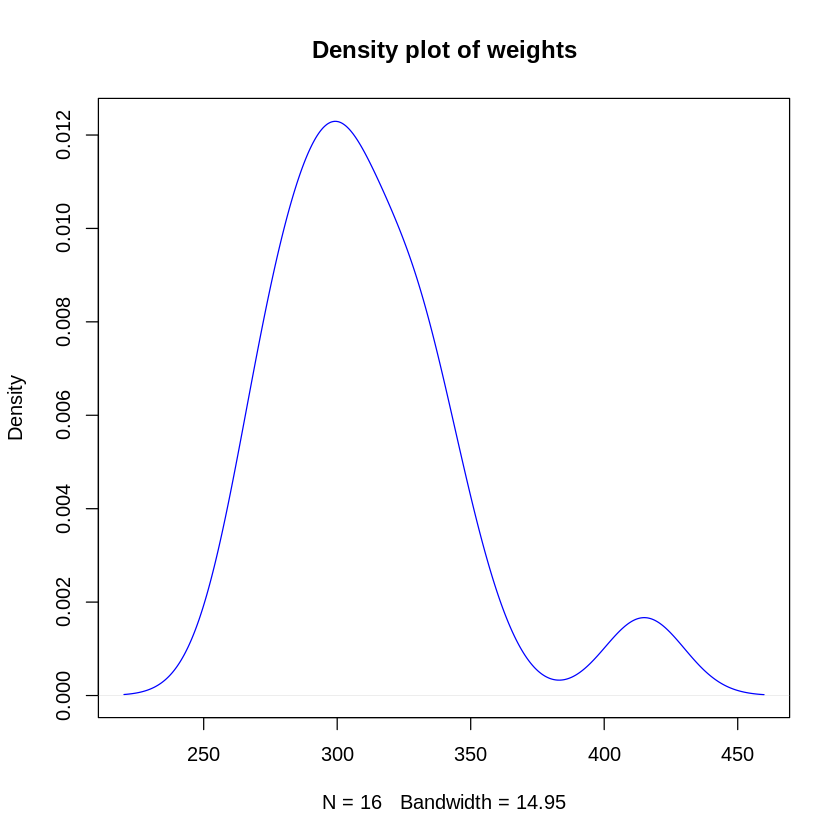

In [ ]:
plot(density(alldata$weight,na.rm=T), main="Density plot of weights",col="blue")
dev.print(file="density.pdf",device=pdf,width=8,height=8)

In this part we will briefly overview genetic markers and their use in association
studies. Then we will discuss step by step how to import data from a small genomic
project, check the data for inconsistencies, fit and evaluate different statistical
models and interpret the results.
**Introduction to Markers**
Genetic markers can be described as a measurable variation (polymorphism) at
the DNA level. They are chromosome regions where differences in nucleotide
sequences occur between individuals of the same species. Various types of markers
have been used to detect DNA variability, the most common being:
• Restriction fragment length polymorphism (RFLP)
• Random amplification of polymorphic DNA (RAPD)
• Amplified fragment length polymorphism (AFLP)
• Single stranded conformation polymorphism (SSCP)
• Copy number variation (CNV)
• Microsatellites
• Single nucleotide polymorphism (SNP)
The last two, microsatellites and SNP are currently the most commonly used
markers—we will focus on these herein. This might be somewhat academic but note
that there is a difference between a genetic marker and DNA variation. A marker
is more related to the technique employed to measure the variation whilst DNA
variation is obviously independent of our ability to measure it or not. When we talk about DNA variation per se we should think more in terms of indels—insertions or
deletions of various lengths; VNTRs—variable number of tandem repeats, which
are multiple copies of the same sequence of DNA, usually simple non-coding
repeats (e.g., AC repeated a certain number of times); and SNP—single nucleotide
polymorphisms which are a single nucleotide mutation (base substitution). SNP
occur in very large numbers and are widely spread across the genome in both coding
and non-coding regions, which makes them ideal for association studies.
The objective of an association study is to link a specific DNA region (and
its underlying variation) with a trait of interest. For example in human research,
many studies have been undertaken to identify genomic regions which confer
greater resistance/susceptibility to diseases such as cancer (an accessible overview
of association studies in cancer is given by Patel et al. [85]), and ultimately, within
these regions, identify the variants that lead to expression of the trait. Knowledge
of these functional variants improves our understanding of disease mechanisms,
suggests targets for novel therapeutics and can be useful for risk prediction and
prevention. For the latter, in a very naive way, this would mean that in the
future a new individual could be genotyped and if he/she has SNP variant A at
location 23445635 on chromosome 3, then this individual has a 26% probability
of developing Alzheimer. In livestock the objective is to find associations that can
explain part of the variance observed in a production trait. For example one of
the variants found in microsatellite marker M is associated with an increase in
marbling of x%. This of course has implications for breeding decisions and can help
improve the accuracy of breeding values. Identification of regions associated with a
trait can also help select candidate regions for gene discovery—that is, identify the
actual genes (“the real biology”) and the functional mutations that confer the trait
differences (e.g., myostatin for double muscling). Note that an association does not
imply causality. A marker can be associated with a trait but it is not necessarily in
any way related to it. Recall that a chromosome is a physical structure of nucleotides
connected to each other which only gets broken up by recombination events. Hence
we can think of DNA sequences being transmitted from parent to offspring in
chunks. The closer the marker is to the actual causative gene, the greater the chance
that the same marker allele will be transmitted to the offspring with the same
causative allelic variant of the gene—the marker and the gene are in linkage, on
the same DNAchunk, or more formally haplotype. A haplotype is er, hmm, a chunk
of DNA which has a combination of alleles that would not be observed by chance
if each one was segregating independently. This brings us to the concept of linkage
disequilibrium (LD): a non-random association of alleles. Pay some attention to
the difference between linkage and linkage disequilibrium. The first is more related
to the actual physical connection of nucleotides on a DNA strand. The second is
more of a statistical concept, we can detect LD with a statistical test of significance
but it is not necessarily telling us anything about the actual physical proximity of
what we are testing (although reasonable inferences can be made).
In short, the terminology is rather telling. Genetic markers mark, they don’t
necessarily cause and association tests identify connections: what we can measure
(marker) is to some extent related to what we want to know (e.g., the true
causative gene).

Just a couple of additional points we should keep in mind: the perfect marker
is a causative marker, as for example the anecdotal SNP we used to exemplify
(partial) susceptibility to Alzheimer. But if the marker is not causal, the further
away it is from our causative gene the greater the chance that a recombination
event will break up the linkage between marker and gene. To illustrate, in our also
anecdotal marbling example if a recombination occurred between marker M and the
true marbling gene in the vicinity of the marker, the favorable variant would then
no longer be useful to track the causal variant.
Microsatellites
Microsatellites are a type of VNTR. If the length of the repeating unit is less than five
base pairs, the VNTR is referred to as a microsatellite. If the length of the repeating
unit is greater than five base pairs the VNTR is called a minisatellite.
Variation in microsatellites is measured through the number of repeats that an
individual has of the repeating unit. For example, back to our AC repeating unit,
one individual might have ten repeats of CA while another has 7. It is immediately
evident that these regions will have different sizes and, if we manage to quantify
them, we can use these measures to distinguish individuals.We can get a handle on
microsatellites using PCR—polymerase chain reaction—methods. Briefly, unique
primers that flank the repeating sequence are used to amplify the region and then
the amplified product is separated by size using a more manual gel electrophoresis
or a high throughput capillary system. We can refer to each of these different sizes
as an allele. Note that diploid organisms will have two of each chromosome and
consequently can have two different microsatellite alleles (heterozygote) or two of
the same (homozygote). Just as a curio, we used the AC example because it is the
most common repeat in humans—dinucleotide repeats are the most frequent and
50% of these are AC.
As we discussed abovemarker alleles are not necessarily causative of the trait we
are interested in. In the case of microsatellite markers it is almost a given that they
are not causative and that they are in non-coding regions (it can’t do much good to a
functional gene to have variable numbers of repeating sequences inside it). Another
point to mention with microsatellites is that they can have many different alleles
(SNP will generally only have two), between 10 and 30 is quite common. This can
be a blessing and a curse at the same time. A single microsatellite marker is much
more informative (many alleles) than one SNP marker (mostly only two alleles).
On the down side, they are much sparser in the genome (microsatellites are in the
thousands while SNP are in the millions) with much lower LD between marker and
causal variant.
We will defer discussing SNP until the next chapter. Here we will limit the
discussion to analysis of microsatellites under the scenario that we have identified a
candidate region from say, a genome wide mapping project, we have
genotyped some microsatellite markers in this region and then we test this fine mapped region for association. Microsatellites have been widely used in QTL
mapping projects and there is an extensive literature in the field in relation to
experimental design and appropriate analytical approaches.

**Case–Control and Family-Based Association Studies**
Case–control is a classic approach used in epidemiological studies. The cases
are individuals who show the disease (in epidemiological or medical research) or
express the trait/condition under study. The control is made up of individuals that
do not express the disease or trait. The objective is to compare the frequency of
alleles and/or genotypes of genetic markers between the two groups to determine
if any of the genotyped polymorphisms are associated with the disease/trait and
what is the probability that this polymorphism will increase/reduce the chance of
the individual (and other individuals in the populationwith the same polymorphism)
expressing the trait or being afflicted by the disease. A point to note is that genotypic
and haplotypic frequencies can vary quite significantly across populations. The
experiment has to be designed is such a way as to minimize or be able to account
for the effect of population stratification which can confound your results. For
example, Korean Hanwoo cattle are highly marbled while Brahman cattle have low
intramuscular fat. If we set up an experiment to contrast Hanwoo and Brahman,
marbling (the trait) would be completely confounded with breed effect. In effect,
breed differences are probably one of the higher order associations that can be
easily picked up by differences in allelic frequencies, as shown in the nice paper
by Hayes et al.. So, to set up a case–control study try to minimize population
stratification by selecting cases and controls with similar genetic backgrounds or at
least select samples in a way that will allow separating population structure from
the trait (somewhat akin to a block design).
Family-based association designs are, as the name suggests, based on family
relationships between individuals in the test. It has the advantage over case–control
studies in the ability to reduce confounding effects of population stratification. The
general principle is to compare siblings which have the same genetic background
and test if either one of the allelic variants of the parent (of course the parent has
to be heterozygous for the marker) is significantly associated with the disease or
trait. As a simple example, take a sire that expresses a trait of interest (e.g., very
high resistance to tick infestation), is heterozygous for a suspect marker and mate
this sire with many homozygous females that do not express the trait, preferably they will be homozygous for a third allele, different from the sire’s alleles. Then
collect phenotypes of the offspring, genotype them for the marker, and test if there
is an association between the allele they inherited from the sire and their level of
resistance to tick infestation. This is a simple example of a half sib design. There are
also full sib designs and other more complex ones. In humans, for obvious reasons,
there’s limited input of the researcher into the mating structure, so it’s common to
work with many small families with a heterozygous parent and one normal/one
affected offspring—the family trio. In livestock there are fewer restrictions on
setting up the experimental design and then questions relating to how many families
and family sizes become extremely relevant. We will not go into any in-depth
details in this text, but power and sample size are critical considerations in genomic
studies and should be given proper attention before embarking on a large scale
experiment.

We immediately see that there are three lines of information that are not part of
the data itself; progdata.txt also has three lines of noise. We start by importing the
data into R and checking if everything looks fine.

In [ ]:
sires=read.table("siredata.txt",header=T,sep="\t",skip=3)
prog=read.table("progdata.txt",header=T,sep="\t",skip=3)
dim(sires)

[1] 10 12

In [ ]:
dim(prog)

[1] 400  14

In [ ]:
print(sires)

       id weight m11 m12 m21 m22 m31 m32 m41 m42 m51 m52
1   sire1 334.14  M2  M1  M3  M2  M3  M4  M4  M2  M4  M2
2   sire2 364.81  M3  M2  M3  M2  M2  M3  M2  M4  M3  M1
3   sire3 383.95  M2  M4  M2  M4  M3  M2  M3  M4  M1  M4
4   sire4 349.88  M2  M1  M1  M2  M4  M3  M2  M1  M4  M3
5   sire5 357.87  M1  M3  M2  M1  M3  M1  M3  M4  M3  M2
6   sire6 364.87  M3  M2  M1  M3  M4  M2  M3  M1  M1  M3
7   sire7 361.36  M4  M1  M4  M1  M2  M1  M1  M2  M2  M4
8   sire8 357.56  M3  M4  M2  M4  M4  M1  M2  M4  M1  M3
9   sire9 333.49  M1  M2  M4  M3  M3  M2  M1  M2  M3  M2
10 sire10 360.92  M2  M3  M3  M1  M3  M2  M2  M3  M3  M2


In [ ]:
head(prog)

,id,sire,sex,weight,m11,m12,m21,m22,m31,m32,m41,m42,m51,m52
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,id1,sire1,F,293.61,M5,M6,M2,M5,M3,M6,M2,M5,M4,M4
2,id2,sire1,M,335.43,M1,M4,M3,M1,M4,M5,M4,M3,M2,M2
3,id3,sire1,M,340.09,M2,M3,M2,M6,M3,M1,M4,M3,M4,M3
4,id4,sire1,M,343.08,M2,M3,M2,M1,M4,M6,M2,M3,M4,M5
5,id5,sire1,F,287.08,M1,M3,M2,M4,M4,M6,M4,M5,M2,M3
6,id6,sire1,F,302.17,M2,M2,M2,M5,M3,M5,M2,M4,M4,M1


So, what have we got on data? In prog we have the animal id, should be a unique
identifier for each animal, we have sex, weight—our trait of interest and the marker
information, one column for each marker and each allele, apparently the first number
refers to the marker and the second to the allele (i.e., m11 is marker one, allele one).
To build genotypes we will have to pool together two columns, but that’s later on.
Let’s summarize the data and see if there’s anything amiss going on.

In [ ]:
summary(sires)

      id                weight          m11                m12           
 Length:10          Min.   :333.5   Length:10          Length:10         
 Class :character   1st Qu.:351.8   Class :character   Class :character  
 Mode  :character   Median :359.4   Mode  :character   Mode  :character  
                    Mean   :356.9                                        
                    3rd Qu.:363.9                                        
                    Max.   :383.9                                        
     m21                m22                m31                m32           
 Length:10          Length:10          Length:10          Length:10         
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                    

In [ ]:
summary(prog)

      id                sire               sex               weight         
 Length:400         Length:400         Length:400         Length:400        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
     m11                m12                m21                m22           
 Length:400         Length:400         Length:400         Length:400        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
     m31                m32                m41                m42           
 Length:400         Length:400         Length:400         Length:400        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
     m51                m52           
 Length:400         Length:400       

The sires data seems fine. For each marker there are four alleles (once we pool
the data from m_1 and m_2 together). Note that the marker allele names are the
same in different markers, this does not mean that the alleles are the same, it just
means that the notation used was to call alleles from m1–mn, where n is the total
number of alleles. Note that microsatellite genotyping is much less automated than,
e.g., SNP genotyping using arrays and labs tend to use ad-hoc formats for the data
(e.g., allele names may be based on fragment size, an official nomenclature or some
internal referencing system). In prog we already see some trouble. Weight which
should be a numeric trait is being treated as a factor, that’s because the notation
used for missing is “-”. We’ll have to fix this. With the markers we also see that
there’s missing data, again using “-”. There also seem to be more alleles than in the
sire group—they must be coming from the dams. Let’s see what the missing weight
looks like, for this we can use the function which

In [ ]:
prog[which(prog$weight=="-"),]

,id,sire,sex,weight,m11,m12,m21,m22,m31,m32,m41,m42,m51,m52
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
90,id90,sire3,M,-,M4,M1,M2,M5,M2,M5,M4,M2,M1,M1


In [ ]:
prog=prog[-which(prog$weight=="-"),]
prog$weight=as.numeric(as.character(prog$weight))
summary(prog$weight)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  282.8   307.0   330.9   329.9   351.8   480.5 

In [ ]:
summary(sires$weight)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  333.5   351.8   359.4   356.9   363.9   383.9 

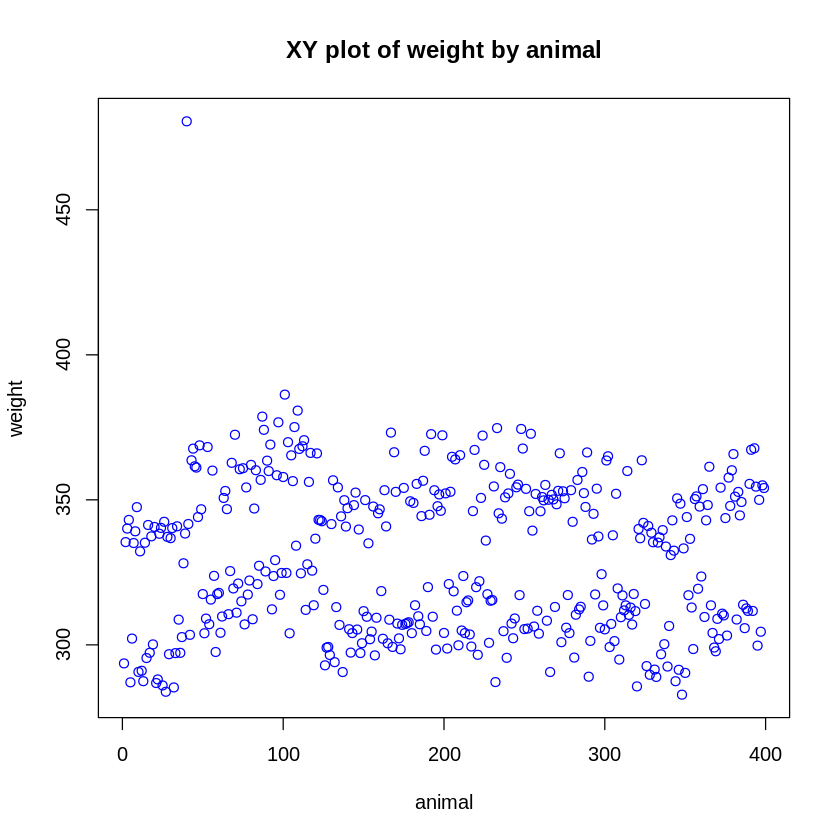

In [ ]:
plot(prog$weight,main="XY plot of weight by animal",xlab="animal",ylab="weight",col="blue")

Figure shows that there is one measurement that is an outlier and the data
seem to be separating very clearly into two groups—we have to keep this in mind.
We could handle the outlier in two ways—go back to the researchers and ask
them about it: does it really make sense, can they go back to the original data and
check it out. Or just remove it from our dataset, let’s do that. From Fig. we know
that the outlier is above 400, we can use which again

In [ ]:
prog=prog[-which(prog$weight>400),]
summary(prog$weight)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  282.8   307.0   330.1   329.5   351.6   386.3 

In [ ]:
index=grep("m",names(prog))
missing=numeric()
for (i in 1:length(index))
missing=c(missing,which(prog[,index[i]]=="-"))
print(missing)

 [1] 69 69 69 69 69 69 69 69 69 69


In [ ]:
missingU=unique(missing)
print(missingU)

[1] 69


There’s quite a lot going on here. First we used the function grep that searches for
pattern matches—it uses regular expressions and it’s a very powerful tool.What we
did was search for the letter m in the header names of prog, this returns the indexes of
the markers. Of course this is overkill here and using a single letter for the searches
is rather dangerous, only do this if you really know the header structure. The point
was just to call attention to the function; try to spend some time learning how to
use grep, it is really handy to find patterns in data. Next we created a new variable
called missing, and defined it as a numeric variable. We had to declare the variable
explicitly because in the next line we use a loop and R will not assign values to a
variable in a loop unless it has been previously declared. The syntax for loops in R
is for(i in x:y), i is the counter, x is the starting value and y is the final value. The
value of i will change in unit increments unless you explicitly modify it. Inside the
loop instead of a hard coded value we used length to find out the actual number of
marker columns—just makes the code more flexible. We used a loop to go over all
marker columns and added to missing the indices of the marker alleles with “-”.
When we print the indices in missing and eyeball the results, we see that there is
a single index repeated across all markers. We can also use the function unique to
get only the unique non-repeated values in missing. Now let’s look at the missing
genotype

In [ ]:
print(prog[missingU,])

     id  sire sex weight m11 m12 m21 m22 m31 m32 m41 m42 m51 m52
70 id70 sire2   M 372.45   -   -   -   -   -   -   -   -   -   -


In [ ]:
prog=prog[-missingU,]

In [ ]:
summary(prog$m11)

   Length     Class      Mode 
      397 character character 

In [ ]:
for (i in 1:length(index))
prog[,index[i]]=factor(prog[,index[i]])
summary(prog$m11)

M1  M2  M3  M4  M5 
 97 139 101  59   1

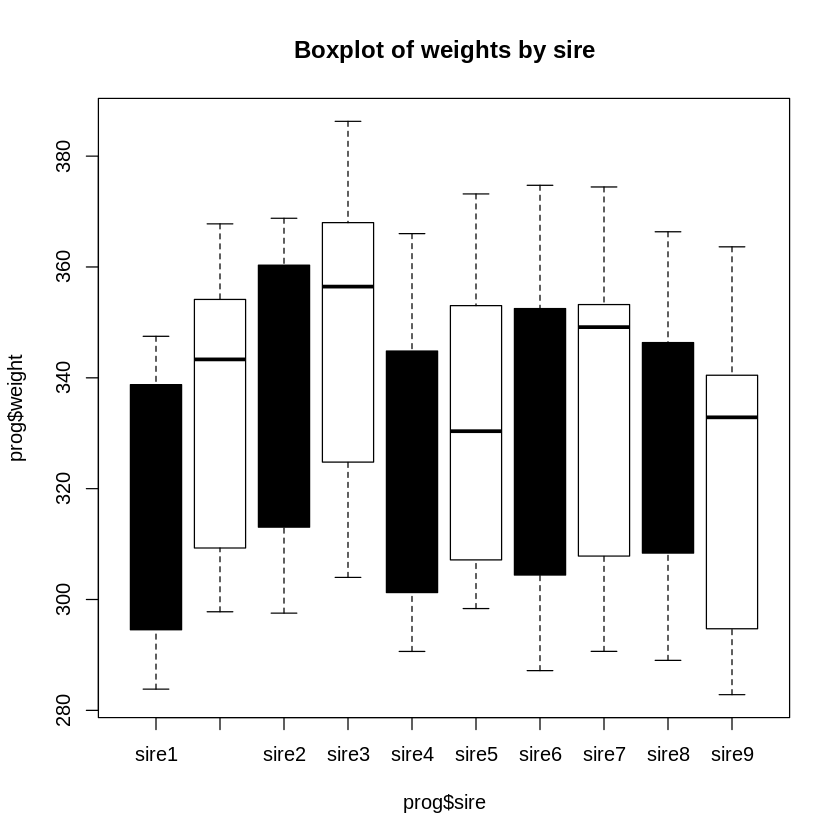

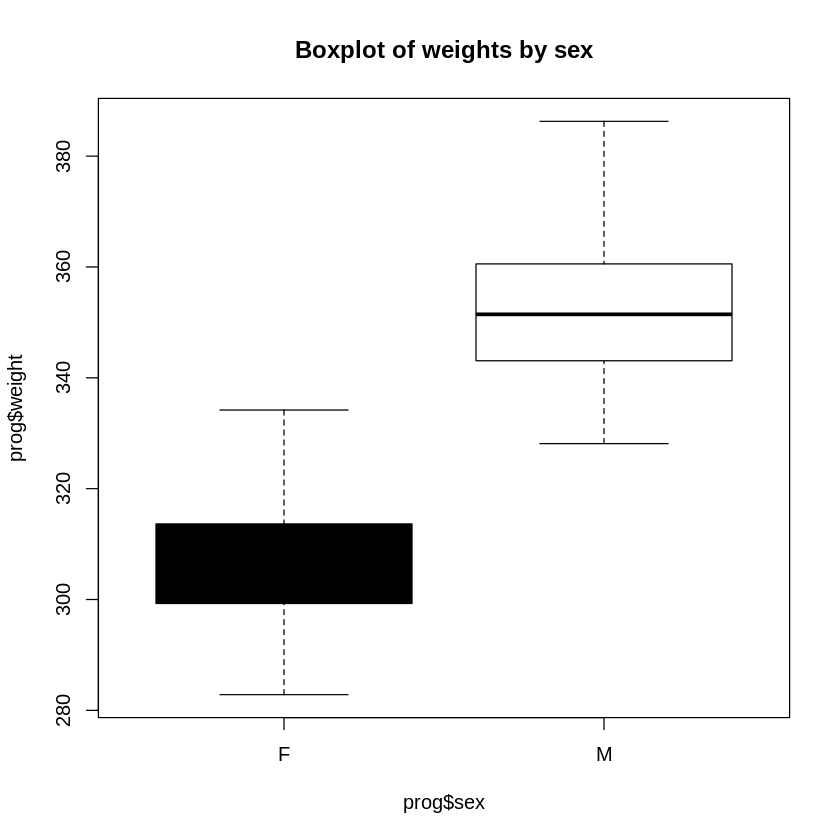

In [ ]:
boxplot(prog$weight~prog$sire,
col=1:length(levels(prog$sire)),
main="Boxplot of weights by sire")
boxplot(prog$weight~prog$sex,
col=1:length(levels(prog$sex)),
main="Boxplot of weights by sex")

Figure above does not show too much difference due to sires. Now, the effect of sex in
Fig. is really large, that’s were our bimodality (Fig.) is coming from. We can show that it really is sex that is splitting our data by repeating the previous
XY plot using sex to color the points (Fig.). Note that we also used the argument
pch to change the symbol used to plot each data point and used legend so we know
what is what. The arguments for legend are position (topleft, bottomright, etc.),
the items [here we used directly the levels in prog$sex but could have used, e.g.,
c(“female”,“male”) instead], the colors (first two in the active palette), and likewise
pch for the symbols.

In our dataset we have genotypes for sires and offspring. One more test we can
do is to see if there are any genotyping errors that we can pick up by comparing
the genotypes of the sires with the genotypes of the offspring.We would expect that
the most common alleles in the offspring would be those that show up in the sire.
In the code below we use grep again to get the indices for the markers in both sires
and prog, then we “bend” these indices into a matrix because we have one column
for one allele and then the next column for the second allele. Next we use library to
load a package called made4 (note: to load packages use library(packagename) but
it needs to be already installed in the library folder). Here we are using a function
(comparelists) in the package to compare two vectors. A new variable compatible is
created to hold the results—the first argument is to say that we want to fill the matrix
with NA, then the dimensions of the matrix (number of sires by number of markers).
The next step is a loop (actually two loops—the first one goes over the markers,
the second one over the sires). For each sire and each marker, we get the alleles of
the sire (variable sirealleles), we summarize the allele counts of the offspring of the
sire, sort these counts in decreasing order and assign the top two to topalleles. Then
we compare sirealleles with topalleles using comparelists and assign the length of
the differences (number of alleles that do not match between the two) to the correct
index in compatible. In this manner we have gone over all sires and all markers and
have a matrix in which any number that is not 0 could be an indication of problems.

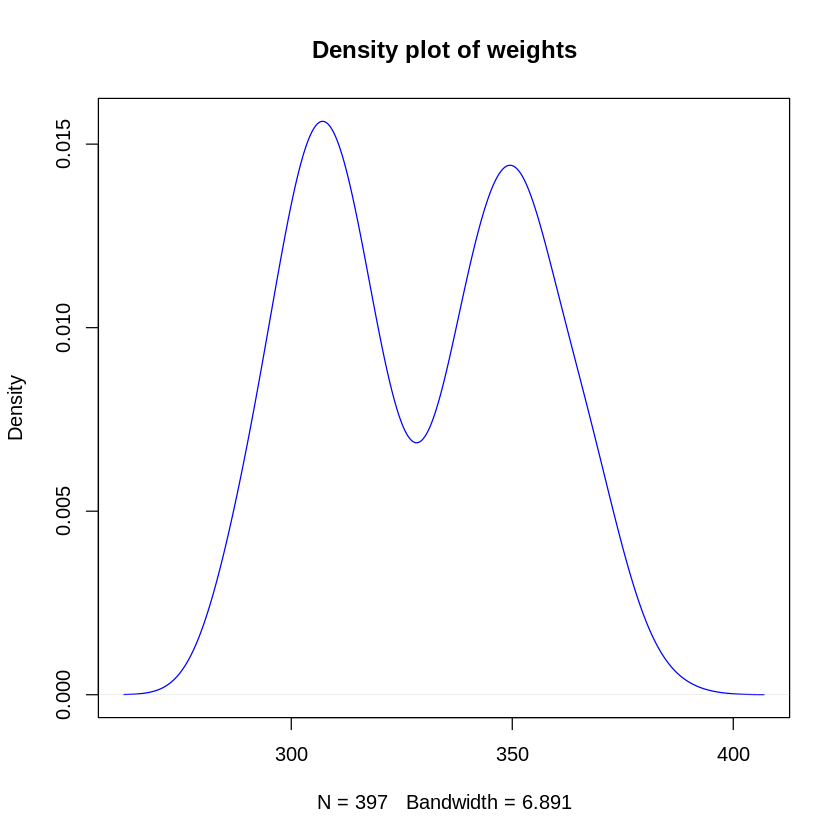

In [ ]:
plot(density(prog$weight),col="blue",
main="Density plot of weights")

In [ ]:
indexms=grep("m",names(sires))
indexms=matrix(indexms,length(indexms)/2,2,byrow=T)
print(indexms)

     [,1] [,2]
[1,]    3    4
[2,]    5    6
[3,]    7    8
[4,]    9   10
[5,]   11   12


In [ ]:
indexm=grep("m",names(prog))
indexm=matrix(indexm,length(indexm)/2,2,byrow=T)
print(indexm)

     [,1] [,2]
[1,]    5    6
[2,]    7    8
[3,]    9   10
[4,]   11   12
[5,]   13   14


In [ ]:
if (!require("BiocManager", quietly = TRUE))
   install.packages("BiocManager")

BiocManager::install("made4")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.20 (BiocManager 1.30.25), R 4.4.2 (2024-10-31)

Installing package(s) 'BiocVersion', 'made4'

also installing the dependencies ‘zlibbioc’, ‘bitops’, ‘matrixStats’, ‘XVector’, ‘UCSC.utils’, ‘GenomeInfoDbData’, ‘abind’, ‘SparseArray’, ‘gtools’, ‘caTools’, ‘BiocGenerics’, ‘MatrixGenerics’, ‘GenomicRanges’, ‘S4Vectors’, ‘IRanges’, ‘GenomeInfoDb’, ‘S4Arrays’, ‘DelayedArray’, ‘pixmap’, ‘sp’, ‘RcppArmadillo’, ‘gplots’, ‘scatterplot3d’, ‘Biobase’, ‘SummarizedExperiment’, ‘ade4’


Old packages: 'cli', 'R6'



In [ ]:
library(made4)
compatible=matrix(NA,length(sires$id),
length(indexms[,1]))
for (j in 1:length(indexms[,1]))
{
for (i in 1:length(sires$id))
{
indexs=which(prog$sire==sires$id[i])
sirealleles=sires[i,indexms[j,]]
sirealleles=c(as.character(sirealleles[,1]),
as.character(sirealleles[,2]))
hold=prog[indexs,indexm[j,]]
hold=factor(c(as.character(hold[,1]),
as.character(hold[,2])))
hold=sort(summary(hold),decreasing=T)
topalleles=names(hold)[1:2]
compatible[i,j]=
length(comparelists(sirealleles,topalleles)$Set.Dif)
if(i==1 & j==1)
{
cat("allele counts in offspring\n")
print(hold)
cat("most common alleles in offspring\n")
print(topalleles)
cat("sire alleles\n")
print(sirealleles)
}
}
}

Loading required package: RColorBrewer

Loading required package: gplots


Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess


Loading required package: scatterplot3d

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, se

allele counts in offspring
M2 M1 M3 M5 M4 M6 
27 26  9  8  6  2 
most common alleles in offspring
[1] "M2" "M1"
sire alleles
[1] "M2" "M1"


In [ ]:
print(compatible)

      [,1] [,2] [,3] [,4] [,5]
 [1,]    0    0    0    0    0
 [2,]    0    0    0    0    0
 [3,]    0    0    0    0    0
 [4,]    0    0    0    0    0
 [5,]    0    0    0    0    0
 [6,]    0    0    0    0    0
 [7,]    0    0    0    0    0
 [8,]    0    0    0    0    0
 [9,]    0    0    0    0    0
[10,]    0    0    0    0    0


Our matrix compatible is filled with zeros. Which means we could not pick up
any inconsistency between sire and offspring genotypes. Our conclusion here is that
the sires were probably genotyped correctly. Unfortunately, real life is much more
complicated, the results will not look so neat if, e.g., there are few offspring per sire,
but I hope this helps to get you started.
Note the use of the if statement. It was used so that the contents of the variables
were printed only once—one sire and one marker (could use this for checking
purposes). The symbol & is the logical and (e.g., IF this is TRUE AND that is also
TRUE then do. . . ). By the way the symbol for logical or is |. The function cat is
similar to print, but a bit prettier!
There are many important aspects in this code.We used a function from a library
(in practice could also have simply used the equivalent function setdiff from the
base installation); built and populated matrices, illustrated the usage of double
loops (rather inefficient in R but handy with not too large datasets), used if to
test a condition and run some other code, used nested functions to collate results
(e.g., sort(summary(hold)).
Now, returning to the problem, let’s flip the question. Given that the sire
genotypes are correct, can we pick up any offspring that might be incorrectly
genotyped? We do basically the same but this time we compare the alleles of the
sire with the alleles in each offspring and check for Mendelian inconsistencies—
at least one of the alleles should be common between the two. There might have
been a mutation but it’s much more likely that it’s a genotyping error. This works
better with markers that have many alleles, if the dam had the same allele(s) as the
sire we would not be able to pick up errors as the offspring would appear to be
consistent with the sire but in reality received the allele from the dam’s side.
The code is similar to what we did before. Variable compatible (note that we are
overwriting the previous matrix) now has one row for each offspring and again one
column for each marker. We also use an additional loop to go over all offspring for
a given sire. Note at the end that we convert compatible to a data.frame and then to
factors (makes the summary more meaningful).We need to first convert the matrix
to a data.frame to be able to change the type of data (from numeric to factor, a matrix
will not let you change the data type on a column by column basis—a matrix can
only hold a single data type).

In [ ]:
compatible=matrix(NA,length(prog$id),
length(indexms[,1]))
for (j in 1:length(indexms[,1]))
{
for (i in 1:length(sires$id))
{
indexs=which(prog$sire==sires$id[i])
sirealleles=sires[i,indexms[j,]]
sirealleles=c(as.character(sirealleles[,1]),
as.character(sirealleles[,2]))
for (k in 1:length(indexs))
{
hold=prog[indexs[k],indexm[j,]]
topalleles=c(as.character(hold[,1]),
as.character(hold[,2]))
compatible[indexs[k],j]=
length(comparelists(sirealleles,topalleles)
$intersect)
}
}
}
compatible=data.frame(compatible)
for (i in 1:length(compatible[1,]))
compatible[,i]=factor(as.character(compatible[,i]))
cat("\nSummary of alleles in common between
sires and offspring\n")


Summary of alleles in common between
sires and offspring


In [ ]:
summary(compatible)

 X1      X2      X3      X4      X5     
 0:  1   1:332   1:326   1:324   1:336  
 1:333   2: 65   2: 71   2: 73   2: 61  
 2: 63                                  

It’s looking good except for the first marker—one animal has no corresponding
allele in its sire. For offspring that have a 2 (two alleles in common with the sire)
we cannot determine which one came from the sire and which one came from the
dam, since in our dataset the dams were not genotyped. There is a workaround
using imputation. We could look at the frequencies of the alleles and try to impute
the allele coming from the sire based on a probability function. Here our data is a
bit too small for that and imputation only really becomes important when we have missing data in our genotypes. But what we have to do is look into the record that
does not have any allele in common with the sire.

In [ ]:
index=which(compatible[,1]==0)
print(prog[index,])

   id  sire sex weight m11 m12 m21 m22 m31 m32 m41 m42 m51 m52
1 id1 sire1   F 293.61  M5  M6  M2  M5  M3  M6  M2  M5  M4  M4


Let’s simply drop the record. This is of course overkill. You would not normally
drop the entire record (you’d just set this marker to NA), after all the other genotypes
seem to be ok. But since we did not have to pay for this data we can afford to be
over conservative and work with the assumption that if one genotype is not correct
we do not trust the others—guilt by association.

In [ ]:
prog=prog[-index,]
dim(prog)

[1] 396  14

Four animal records were removed from our dataset—just one percent. But don’t
expect such good data from real experiments.
The next thing we can do with the data is plot the genotypic and allelic
frequencies. Let’s work with data from the first marker across all families.
First we have to summarize the count data for alleles

In [ ]:
#Single marker test
alleles=summary(factor(c(as.character(prog$m11),
as.character(prog$m12))))
print(alleles)

 M1  M2  M3  M4  M5  M6 
166 207 167 121  74  57 


In [ ]:
alleles=alleles/sum(alleles)
print(alleles)

        M1         M2         M3         M4         M5         M6 
0.20959596 0.26136364 0.21085859 0.15277778 0.09343434 0.07196970 


In [ ]:
#That was easy. The function sum does what you’d expect. And now for
#genotypes. . .
hold=data.frame(m11=as.character(prog$m11),
m12=as.character(prog$m12))
hold[,1]=as.character(hold[,1])

In [ ]:
hold[,2]=as.character(hold[,2])
sorted=character()
for (i in 1:length(hold[,1]))
sorted=rbind(sorted,sort(as.character(hold[i,])))
genotypes=paste(as.character(sorted[,1]),
as.character(sorted[,2]),sep="_")
genotypes=summary(factor(genotypes))
print(genotypes)

M1_M1 M1_M2 M1_M3 M1_M4 M1_M5 M1_M6 M2_M2 M2_M3 M2_M4 M2_M5 M2_M6 M3_M3 M3_M4 
   14    42    34    22    26    14    28    35    38    17    19    21    24 
M3_M5 M3_M6 M4_M4 M4_M5 M4_M6 
   19    13     7    12    11 


In [ ]:
genotypes=genotypes/sum(genotypes)
print(genotypes)

     M1_M1      M1_M2      M1_M3      M1_M4      M1_M5      M1_M6      M2_M2 
0.03535354 0.10606061 0.08585859 0.05555556 0.06565657 0.03535354 0.07070707 
     M2_M3      M2_M4      M2_M5      M2_M6      M3_M3      M3_M4      M3_M5 
0.08838384 0.09595960 0.04292929 0.04797980 0.05303030 0.06060606 0.04797980 
     M3_M6      M4_M4      M4_M5      M4_M6 
0.03282828 0.01767677 0.03030303 0.02777778 


That was much less simple. The problem here is that we have to merge the two
alleles together to form the genotype. And not only that, we have to make sure that
AB is not considered different from BA. First we created a temporary data.frame to
hold the two alleles, then a new variable to hold the sorted order of the alleles was
used—sorted. Next we sorted each pair of alleles using a loop and added the sort
order to sorted. Finally, we merged the sorted alleles into a single genotype using
the function paste which concatenates strings. The rest is the same as we did with
the alleles.
Now for plotting. The functions split.screen and screen are a handy way of
placing more than one image in a single plot area (instead of having to make two
separate plots

[1] 1 2

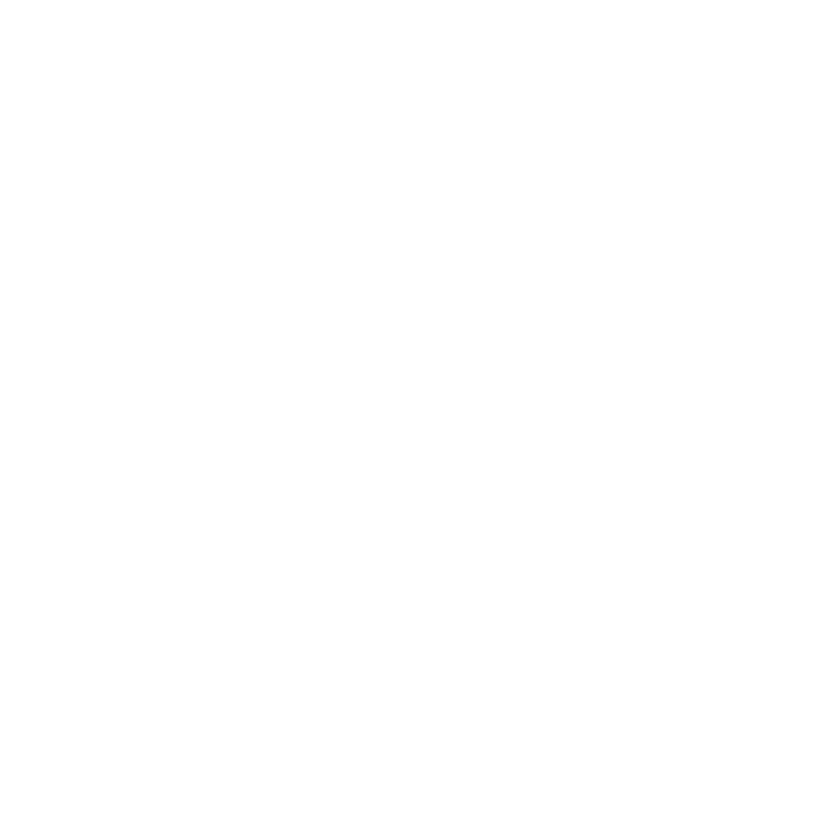

In [ ]:
split.screen(c(2,1))

Warning message in par(new = TRUE):
“calling par(new=TRUE) with no plot”


pdf 
  2

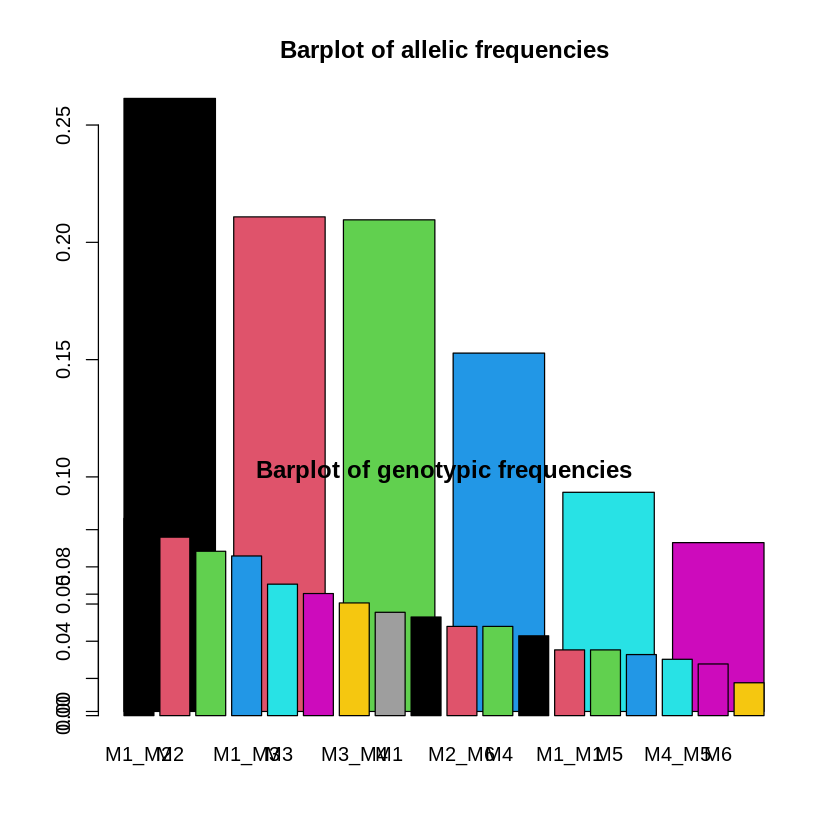

In [ ]:
screen(1)
barplot(sort(alleles,decreasing=T),col=1:11,
main="Barplot of allelic frequencies")
screen(2)
barplot(sort(genotypes,decreasing=T),col=1:11,
main="Barplot of genotypic frequencies")
close.screen(all = TRUE)
dev.print(file="animgeno.pdf",
device=pdf,width=8,height=8)

We sorted the frequencies in decreasing order before plotting.We can see that the
most frequent alleles are the ones coming from the sires. Recall the use of dev.print
for saving plots.
For the analysis we will use a genotype model. Let’s make a new data.frame with
the same information but with a single column for the genotypes for each marker
instead of two columns with alleles. We can do exactly the same as before and just
add a loop and a new variable allgeno to store the genotypes. Then we create a new
data.frame with the progeny data and the genotypes called markers.

In [ ]:
allgeno=NULL
for(i in 1:length(indexm[,1]))
{
hold=data.frame(prog[indexm[i,]])
hold[,1]=as.character(hold[,1])
hold[,2]=as.character(hold[,2])
sorted=character()
for (i in 1:length(hold[,1]))
sorted=rbind(sorted,sort(as.character(hold[i,])))
genotypes=paste(as.character(sorted[,1]),
as.character(sorted[,2]),sep="_")
allgeno=cbind(allgeno,genotypes)
}
colnames(allgeno)=c("M1","M2","M3","M4","M5")
markers=data.frame(prog[,1:4],allgeno)

In [ ]:
head(markers)

,id,sire,sex,weight,M1,M2,M3,M4,M5
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
2,id2,sire1,M,335.43,M1_M4,M1_M3,M4_M5,M3_M4,M2_M2
3,id3,sire1,M,340.09,M2_M3,M2_M6,M1_M3,M3_M4,M3_M4
4,id4,sire1,M,343.08,M2_M3,M1_M2,M4_M6,M2_M3,M4_M5
5,id5,sire1,F,287.08,M1_M3,M2_M4,M4_M6,M4_M5,M2_M3
6,id6,sire1,F,302.17,M2_M2,M2_M5,M3_M5,M2_M4,M1_M4
7,id7,sire1,M,335.11,M1_M2,M1_M2,M3_M3,M2_M4,M2_M5


In [ ]:
#Now that we have cleaned the data, let’s save it so that if we decide to rerun the
#analysis later on we don’t need to go through all the cleaning steps again.
write.table(markers,"cleandata.txt",
quote=F,sep="\t",row.names=F)

At long last we are ready to analyze the data. This is quite common with genomic
data (and almost all statistical analyses for that matter), more than half of the work
involves cleaning up and preprocessing.
We want to test the markers with a continuous trait (weight) for association.
A good way to go about it is with a linear model for analysis of variance (anova).
Here is where R comes into its own. We can use the function lm to fit models, it
can handle regressions, analysis of variance and analysis of covariance. The syntax
is lm(formula=mymodel, data=mydata), there are other arguments such as how
to handle missing data, what weights should be used in the fitting process, you
can define a specific subset of the data to be used and also a list of contrasts to
be tested (see the help page for details). The argument data is just the name of
the data.frame that will be used in the analysis. Instead of having to use the full
name (data.frame$headername) as we have been using so far, you can then use only
the header names in the formula and these will be picked up from the data.frame
specified in data.

In [ ]:
attach(sires)
print(id)

 [1] "sire1"  "sire2"  "sire3"  "sire4"  "sire5"  "sire6"  "sire7"  "sire8" 
 [9] "sire9"  "sire10"


In [ ]:
detach(sires)

Just be careful, for example if you attach both sires and prog you will run into
trouble because of the names in common that are in both data.frames. It’s probably
best not to attach a data.frame but if you do, remember to detach it when you are
finished—this removes the direct access and its consequences from R’s workspace.
To exemplify the problem

In [ ]:
attach(sires)
attach(prog)
detach(sires)
detach(prog)

The following objects are masked from sires:

    id, m11, m12, m21, m22, m31, m32, m41, m42, m51, m52, weight




Now, the important part is our model formula. The syntax is somewhat similar to
how we would normally write a model y ∼ x1 +x2 +xn. As we mentioned before,
the tilde symbol ˜ means “modeled by”. On the left-hand side we have our response
variable and on the right-hand side our explanatory variables. For our data we could
test something along the lines of weight ˜ M1. This models weight in relation to the
genotypes of marker 1. The full R syntax is
lm(weight ˜ M1, data=markers)

In [ ]:
lm(weight~M1,data=markers)


Call:
lm(formula = weight ~ M1, data = markers)

Coefficients:
(Intercept)      M1M1_M2      M1M1_M3      M1M1_M4      M1M1_M5      M1M1_M6  
  3.253e+02    1.771e+00    2.256e+00    8.919e+00   -1.372e+00    7.143e-04  
    M1M2_M2      M1M2_M3      M1M2_M4      M1M2_M5      M1M2_M6      M1M3_M3  
 -1.049e+00    9.872e+00   -3.144e-01   -2.640e+00    1.145e+01    4.787e+00  
    M1M3_M4      M1M3_M5      M1M3_M6      M1M4_M4      M1M4_M5      M1M4_M6  
  7.156e+00    1.295e+01    8.932e+00    1.955e+01    1.065e+01    6.623e-02  


In [ ]:
results=lm(weight~M1,data=markers)
class(results)

[1] "lm"

In [ ]:
#Our variable results is of class lm, which is a class that holds results from a linear
#model and has quite a few methods that can be applied to it.
summary(results)


Call:
lm(formula = weight ~ M1, data = markers)

Residuals:
    Min      1Q  Median      3Q     Max 
-46.185 -22.118   1.607  21.368  52.109 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  3.253e+02  6.763e+00  48.095   <2e-16 ***
M1M1_M2      1.771e+00  7.809e+00   0.227   0.8207    
M1M1_M3      2.256e+00  8.035e+00   0.281   0.7790    
M1M1_M4      8.919e+00  8.651e+00   1.031   0.3032    
M1M1_M5     -1.372e+00  8.388e+00  -0.164   0.8702    
M1M1_M6      7.143e-04  9.564e+00   0.000   0.9999    
M1M2_M2     -1.049e+00  8.283e+00  -0.127   0.8993    
M1M2_M3      9.872e+00  8.002e+00   1.234   0.2181    
M1M2_M4     -3.144e-01  7.911e+00  -0.040   0.9683    
M1M2_M5     -2.640e+00  9.132e+00  -0.289   0.7727    
M1M2_M6      1.145e+01  8.913e+00   1.284   0.1998    
M1M3_M3      4.787e+00  8.731e+00   0.548   0.5838    
M1M3_M4      7.156e+00  8.510e+00   0.841   0.4009    
M1M3_M5      1.295e+01  8.913e+00   1.453   0.1472    
M1M3_M6      8.93

Now we get the model formula, the range of the residuals of our fitted data and
the coefficients with the estimates for each class, the standard errors of the estimates,
the t-values and the p-values.And also the usual significance stars. We also get some
additional information regarding residual standard errors and number of degrees of
freedom, goodness of fit of the model with the R-squared and adjusted R-squared,
and so on. We will only focus on the interpretation of the output, readers interested
in a step by step walkthrough of the calculations might enjoy the introductory book
by Crawley [21] or, for a more in-depth theoretical exposition, Faraway’s [31] book
is a good reference.
It’s always a good idea to have a quick look at the (adjusted) R squared or
the p-value of the F-statistic. It’s not necessarily decisive in model selection but
it does provide a broad indication if the model is actually explaining any part of
the observations or not. In our example we can see that it’s a rather poor fit—
the adjusted R-squared is almost zero. It’s also a good idea to check if the model
is behaving sensibly (if our assumptions are not too strong—e.g., data is normal,
residuals are well behaved, variance is not changing based on our measures). Use
plot(lmobject) to get four “quality control” plots of your model (there are actually
six plots, but four are shown by default). The first two are the most interesting, an
xy plot of fitted by residual values and a QQ plot of theoretical normal quantiles
by residual quantiles. Just using plot on an lmobject is the most convenient way for
plotting, but you can also make the plots yourself. To extract the fitted values from
an lmobject use the function predict and for the residuals the function residuals
(that’s another two more methods for an lmobject), then just plot one against the
other

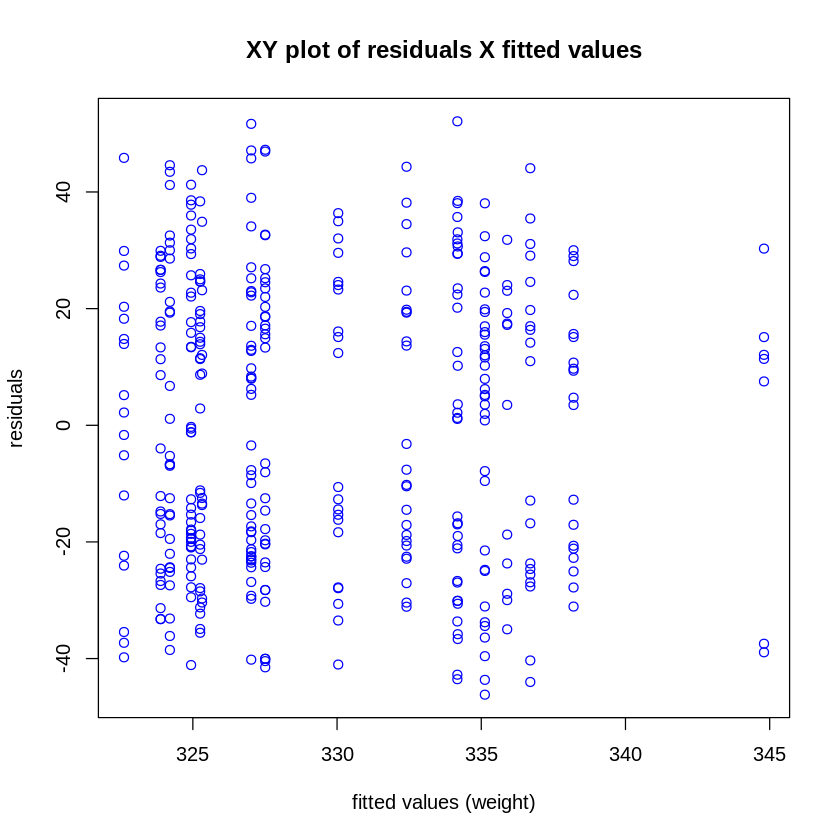

In [ ]:
plot(predict(results),residuals(results),
main="XY plot of residuals X fitted values",
xlab="fitted values (weight)",
ylab="residuals",col="blue")

[1] 1 2

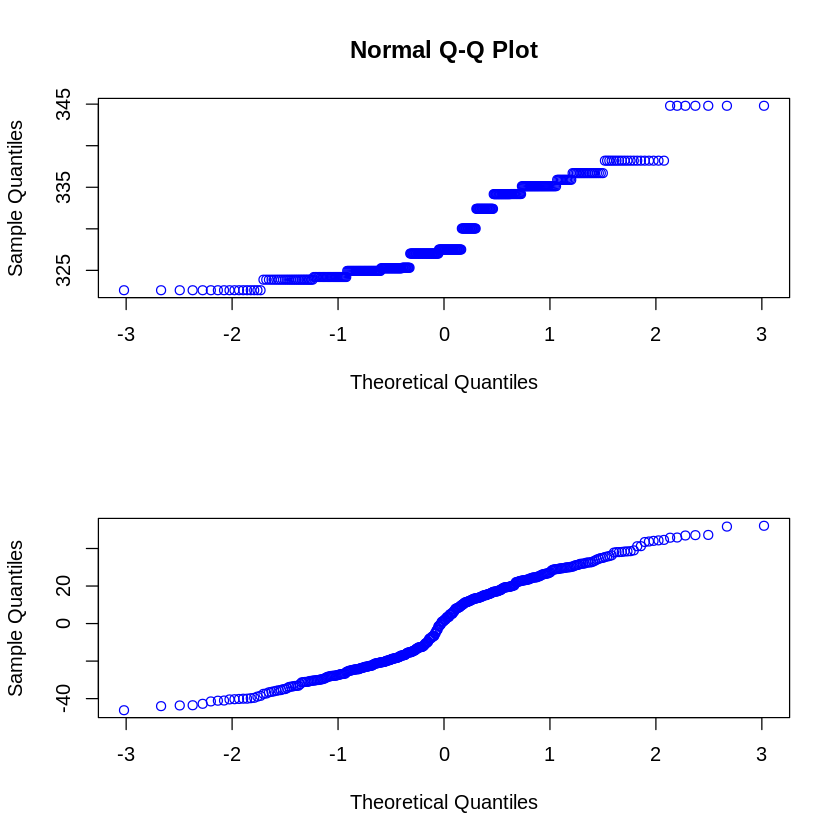

In [ ]:
#We do not observe too much of a pattern in the plot so the variance is
#constant (or at least constant enough). For a normal QQ plot
split.screen(c(2,1))
screen(1)
qqnorm(predict(results),col="blue")
screen(2)
qqnorm(residuals(results),col="blue",main="")
close.screen(all = TRUE)

The top plot shows the fitted values against the normal theoretical
quantiles and the lower plot shows the same but for the residuals (which would be
the second plot given by plot(results)). Note that in terms of normality we have
nothing to write home about. I’m sure we can blame the effect of sex for it!

In [ ]:
#Another two functions that come in handy to check the data are fligner.test for
#homogeneity of variances and shapiro.test for normality.
fligner.test(weight~M1,data=markers)


	Fligner-Killeen test of homogeneity of variances

data:  weight by M1
Fligner-Killeen:med chi-squared = 7.6979, df = 17, p-value = 0.9726


In [ ]:
shapiro.test(prog$weight)


	Shapiro-Wilk normality test

data:  prog$weight
W = 0.94831, p-value = 1.548e-10


Once we are satisfied that nothing too amiss is going on with our model, we can
interpret the results. In the summary table we have Estimate, Std. Error, t value,
and Pr(>|t|). It’s quite straightforward. The estimate is the estimated mean value for levels and all other values are shown as a deviation from this top value (R by default
uses a treatment–contrast parameterization). The baseline is selected in alphabetical
order (in our example M1_M1), so if you want a different baseline you’ll need to
reorder the levels. The standard errors are, as you would expect, the uncertainty
around the estimates and the last column shows the p-values. Note that the p-values
are always in relation to the baseline factor.
Another useful function is anova which is essentially just a different output for an
lmobject as a standard anova table (a good way to quantify the effect of explanatory
variables).

In [ ]:
anova(results)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
M1,17,10928.04,642.8257,1.003967,0.4528779
Residuals,378,242028.02,640.2858,NA,NA


The marker is not significant (does not explainmuch of the variability in weight).
We know this model has little explanatory power, but we also know that sex seems
to have a pretty big effect on our data. Let’s include sex in the model

In [ ]:
summary(lm(weight~sex+M1,data=markers))


Call:
lm(formula = weight ~ sex + M1, data = markers)

Residuals:
     Min       1Q   Median       3Q      Max 
-23.1174  -7.2400  -0.7689   7.1190  31.3916 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 2.992e+02  2.900e+00 103.168  < 2e-16 ***
sexM        4.558e+01  1.081e+00  42.143  < 2e-16 ***
M1M1_M2     6.111e+00  3.274e+00   1.867 0.062693 .  
M1M1_M3     5.512e+00  3.368e+00   1.637 0.102537    
M1M1_M4     1.010e+01  3.625e+00   2.787 0.005590 ** 
M1M1_M5     1.884e+00  3.516e+00   0.536 0.592370    
M1M1_M6     7.143e-04  4.007e+00   0.000 0.999858    
M1M2_M2     7.090e+00  3.476e+00   2.040 0.042079 *  
M1M2_M3     5.965e+00  3.354e+00   1.779 0.076118 .  
M1M2_M4     7.739e+00  3.320e+00   2.331 0.020292 *  
M1M2_M5     4.637e+00  3.830e+00   1.211 0.226794    
M1M2_M6     1.350e+01  3.735e+00   3.615 0.000341 ***
M1M3_M3     9.128e+00  3.660e+00   2.494 0.013051 *  
M1M3_M4     1.421e+01  3.569e+00   3.981 8.24e-05 ***
M1M3_M5     1.26

That is a big effect! It is highly significant and we expect males to be around
46 kg heavier than females. That’s a lot more than any of the other effects. And the
adjusted R-squared is also looking much better at over 0.82 (largely due to sex).
And now a lot of genotypes seem to have an effect. So, that’s that for marker 1? Not
quite.We have not considered the effect of sire in our model

In [ ]:
summary(lm(weight~sex+sire+M1,data=markers))


Call:
lm(formula = weight ~ sex + sire + M1, data = markers)

Residuals:
     Min       1Q   Median       3Q      Max 
-20.5650  -5.7110  -0.0889   5.2261  21.5778 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 293.8628     2.6104 112.574  < 2e-16 ***
sexM         45.5573     0.8566  53.186  < 2e-16 ***
siresire10   14.5459     1.9541   7.444 7.00e-13 ***
siresire2    18.2750     2.0120   9.083  < 2e-16 ***
siresire3    27.9691     2.0110  13.908  < 2e-16 ***
siresire4     8.5190     1.9165   4.445 1.16e-05 ***
siresire5    14.2383     1.9915   7.150 4.72e-12 ***
siresire6    15.8241     2.0043   7.895 3.37e-14 ***
siresire7    14.2136     2.0673   6.875 2.66e-11 ***
siresire8    14.1905     2.1265   6.673 9.22e-11 ***
siresire9     3.6338     1.9234   1.889   0.0596 .  
M1M1_M2       1.0713     2.6239   0.408   0.6833    
M1M1_M3      -0.7715     2.7549  -0.280   0.7796    
M1M1_M4       0.9751     3.0089   0.324   0.7461    
M1M1_M5      -1.6311    

Sire also seems to have quite a large influence on our data and note that the
variation that before was attributed to the marker is now being captured by the sires.
Be careful when interpreting these p-values, remember that they reflect differences
from the base level (here sire 1).We could have a scenario with all sires significantly
different from sire 1 but not different between themselves. They would all seem to
be significant but the actual variation explained by sire might not be. For example,
sires 5, 7 and 8 are all quite similar to each other (the estimated difference between
sires 7 and 8 is only 22.1 g—14.2136−14.1905= 0.0221). Note that sire 3 has the
highest p-value (0.0596) and is also the one with the smallest difference (3.6338 kg)
from sire 1. Coincidentally sire 1 has the lightest offspring (on average), hence all
coefficients are positive. So, these p-values do not tell us how much of the variation
is explained by the sires and we still do not know if the term is significant enough
to be worthwhile keeping in the model. To formally test the difference in models
(essentially proportion of variation explained by a term) do an anova on them.

In [ ]:
model1=lm(weight~sex+sire+M1,data=markers)
model2=lm(weight~sex+M1,data=markers)
model3=lm(weight~M1,data=markers)
anova(model1,model2)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,368,25369.86,NA,NA,NA,NA
2,377,42378.81,-9,-17008.95,27.41351,3.187974e-36


Sire has a highly significant effect in our model and the term should be kept. Out
of completeness we also ran an anova test to see if we had to keep sex and of course,
no questions there. In summary to test if a term should be kept or deleted from a
model, build the models you want to try, store them as an mobject and then compare
them using an anova.We can also test our model against a null model—amodel that
has no explanatory power at all.

In [ ]:
model4=lm(weight~1,data=markers)
anova(model3,model4)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,378,242028.0,NA,NA,NA,NA
2,395,252956.1,-17,-10928.04,1.003967,0.4528779


And this confirms it—our marker is not providing any information at all. But
we already knew that from the R-squared and anova. Note that the p-value above
(0.4529) and the p-values from the anova and from the F-statistic given by summary
that we obtained with the model fitting only the marker are exactly the same—as
they should be. In contrast look at sex

In [ ]:
anova(model2,model4)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,377,42378.81,NA,NA,NA,NA
2,395,252956.06,-18,-210577.2,104.0714,6.149896e-134


So far we have not mentioned interactions between terms. If we wanted a fully
saturated model with all terms and interactions (and completely inestimable from
this data) it would look like
weight ˜ sex*sire*M1
The symbol * is used to model the main effect and the interactions. To estimate
only the interactions use sex:sire. For quadratic terms use ˆ2, consult the R help
files for details. This analysis was for the first marker across all families (but we did
include sire in the model). We could also look at the effects on a per sire, single
family model. For the first sire it would be

In [ ]:
summary(lm(weight~sex+M1,
data=markers[which(prog$sire=="sire1"),]))


Call:
lm(formula = weight ~ sex + M1, data = markers[which(prog$sire == 
    "sire1"), ])

Residuals:
    Min      1Q  Median      3Q     Max 
-9.1959 -3.9096  0.0613  3.8731 12.6641 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 292.0005     3.9627  73.687   <2e-16 ***
sexM         44.0293     2.4834  17.730   <2e-16 ***
M1M1_M2       4.0354     4.1938   0.962    0.344    
M1M1_M3      -0.7563     4.6992  -0.161    0.873    
M1M1_M4      -0.5998     7.2481  -0.083    0.935    
M1M1_M5       2.6276     4.7673   0.551    0.586    
M1M1_M6       4.2302     7.2481   0.584    0.564    
M1M2_M2       1.7728     5.3540   0.331    0.743    
M1M2_M3       5.1777     4.8342   1.071    0.294    
M1M2_M4       1.0178     4.6020   0.221    0.827    
M1M2_M5      -0.1500     5.0916  -0.029    0.977    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.236 on 27 degrees of freedom
Multiple R-squared:  0.9484,	Adjusted R-

The across families model is preferable—provided the marker and gene are fully
linked, they will not recombine and the phases in the sire families are the same.
If we run the same model with sex and sire for the other markers we get

In [ ]:
summary(lm(weight~sex+sire+M2,data=markers))


Call:
lm(formula = weight ~ sex + sire + M2, data = markers)

Residuals:
     Min       1Q   Median       3Q      Max 
-22.7912  -5.6914  -0.5605   4.9794  23.5298 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 294.07371    2.56442 114.674  < 2e-16 ***
sexM         45.61291    0.86016  53.028  < 2e-16 ***
siresire10   15.96557    1.95229   8.178 4.74e-15 ***
siresire2    19.33987    1.94433   9.947  < 2e-16 ***
siresire3    27.56248    2.08319  13.231  < 2e-16 ***
siresire4     9.04794    2.01229   4.496 9.28e-06 ***
siresire5    14.91096    1.99842   7.461 6.23e-13 ***
siresire6    17.24295    1.96925   8.756  < 2e-16 ***
siresire7    15.51597    2.08658   7.436 7.36e-13 ***
siresire8    14.52662    2.04696   7.097 6.61e-12 ***
siresire9     3.64002    1.98009   1.838   0.0668 .  
M2M1_M2      -1.35543    2.52170  -0.538   0.5912    
M2M1_M3      -1.91512    2.40510  -0.796   0.4264    
M2M1_M4      -4.73051    2.72847  -1.734   0.0838 .  
M2M1_M5  

In [ ]:
summary(lm(weight~sex+sire+M3,data=markers))


Call:
lm(formula = weight ~ sex + sire + M3, data = markers)

Residuals:
     Min       1Q   Median       3Q      Max 
-23.3480  -5.8414  -0.3709   4.6576  23.8250 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 295.7821     3.4113  86.705  < 2e-16 ***
sexM         45.3620     0.8563  52.972  < 2e-16 ***
siresire10   14.5426     2.0227   7.190 3.65e-12 ***
siresire2    19.8409     2.0035   9.903  < 2e-16 ***
siresire3    27.9406     2.0000  13.970  < 2e-16 ***
siresire4     8.6615     1.9331   4.481 9.95e-06 ***
siresire5    15.1641     2.0205   7.505 4.67e-13 ***
siresire6    16.4759     1.9655   8.383 1.11e-15 ***
siresire7    15.0614     2.0775   7.250 2.48e-12 ***
siresire8    14.5809     1.9743   7.386 1.03e-12 ***
siresire9     3.2624     2.0031   1.629    0.104    
M3M1_M2      -1.7039     3.4520  -0.494    0.622    
M3M1_M3      -2.7986     3.3179  -0.843    0.400    
M3M1_M4      -3.5924     3.5067  -1.024    0.306    
M3M1_M5      -5.2669    

In [ ]:
summary(lm(weight~sex+sire+M4,data=markers))


Call:
lm(formula = weight ~ sex + sire + M4, data = markers)

Residuals:
     Min       1Q   Median       3Q      Max 
-22.7806  -5.8261  -0.0981   5.2882  23.2222 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 295.6093     3.1683  93.301  < 2e-16 ***
sexM         45.7384     0.8595  53.213  < 2e-16 ***
siresire10   15.7858     1.9570   8.066 1.03e-14 ***
siresire2    19.7087     1.9245  10.241  < 2e-16 ***
siresire3    28.1588     1.9848  14.187  < 2e-16 ***
siresire4     7.6661     2.0518   3.736 0.000216 ***
siresire5    14.7326     1.9683   7.485 5.33e-13 ***
siresire6    16.2506     2.0735   7.837 5.01e-14 ***
siresire7    14.5987     1.9936   7.323 1.54e-12 ***
siresire8    15.1862     1.9403   7.827 5.38e-14 ***
siresire9     3.1479     2.0130   1.564 0.118734    
M4M1_M2      -4.0779     2.9327  -1.391 0.165216    
M4M1_M3      -3.2466     3.1855  -1.019 0.308782    
M4M1_M4      -2.2060     3.0873  -0.715 0.475355    
M4M1_M5      -0.2960    

In [ ]:
summary(lm(weight~sex+sire+M5,data=markers))


Call:
lm(formula = weight ~ sex + sire + M5, data = markers)

Residuals:
    Min      1Q  Median      3Q     Max 
-14.192  -3.152  -0.124   3.451  13.538 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  305.860      1.813 168.731  < 2e-16 ***
sexM          46.151      0.519  88.921  < 2e-16 ***
siresire10    14.829      1.181  12.553  < 2e-16 ***
siresire2     10.591      1.299   8.151 5.72e-15 ***
siresire3     18.050      1.276  14.144  < 2e-16 ***
siresire4      6.169      1.200   5.139 4.48e-07 ***
siresire5     13.321      1.185  11.237  < 2e-16 ***
siresire6      9.559      1.283   7.449 6.77e-13 ***
siresire7     12.990      1.193  10.889  < 2e-16 ***
siresire8      5.610      1.334   4.205 3.29e-05 ***
siresire9      1.308      1.188   1.101   0.2717    
M5M1_M2        1.505      1.804   0.834   0.4046    
M5M1_M3        2.329      1.699   1.371   0.1713    
M5M1_M4        3.405      1.794   1.898   0.0585 .  
M5M1_M5        1.928      1.923   

Nothing much is really happening until we get to the last marker—then we get
stars everywhere. For the first four markers only a few genotypes are marginally
significant and none of them would make it past a p-value cutoff of 0.05. They
also have reasonably small effects, the largest one being around 6 kg, the standard
deviation is 25 kg, so just around 0.2 of a standard deviation). Our first four markers
were not very exciting. But how do we interpret the results from the fifth marker?
Sex is still significant and adds around 46 kg to the weight of males. The sires
are different between each other, we hope to have captured the polygenic effects
reasonably well. Recall that the differences are shown in relation to sire 1 and most
sires are significantly different from it but not necessarily different between each
other. Note that the estimates of sire effects change when differentmarkers are fitted
but are still reasonably consistent (the standard errors can help with confidence of
estimates).
As for the markers our baseline genotype is M1_M1, homozygote for allele M1.
There are in total 18 genotypes in our data for this marker. We see that the first 5
were not significant and the other 12 were (17 because one is the baseline contrast).
If we look closely at the first 5 we will notice that all of them have an allele M1 in
the genotype, but the others do not. And that’s our result: allele M1 has a significant effect on our trait. What else can we say? Allele M1 is dominant—remember that
the baseline is M1_M1 and we are getting almost the same estimates for one or
two “doses” of allele M1. The allele cannot be recessive because then the difference
between the homozygoteM1_M1 and the heterozygotes would have to be similar to
the difference between having or not allele M1 (similar to the other 12 values). Could
it be additive? Again we would expect a consistent intermediate value between 0,
1 and 2 copies of the allele—which we do not see here; if anything the estimates
for the heterozygotes seem positive. Of course there might be different interactions
between allele M1 and each of the other alleles, but that’s another story. . . The mean
of the estimates for genotypes that do not carry allele M1 is −13.52 kg; thus animals
with allele M1 will be almost 14 kg heavier than other animals.
Our grand conclusion: the candidate gene in linkage with marker 5 is a
potential suspect for having an effect and influencing weight in cattle. Animals
which carry allele M1 from marker 5 should show an additional weight gain
of around 14 kg in relation to other animals. The favorable allele shows a
dominance effect.
That’s the end of this analysis. Did it actually work? I would say yes. The
simulation was based on a mean weight for males of 350 kg (sd = 10), females
300 kg (sd = 10) and only marker 5, allele M1 had an effect of 15 kg (sd = 2) and
the allele was set up to be dominant.
Some things to keep in mind. This exercise was highly guided—the parameterization
worked well. In real life it’s not common that the baseline will work so
nicely. First, ignore p-values and focus on estimates of the effects, that’s much
more meaningful and you will be able to pick the relationships between levels
right away. The main value of the p-values is to evaluate your confidence in the
estimate of effects given the data. Also, even if an effect is significant, it might be so
small as to have little value anyhow (and the opposite is true as well). If you don’t
like treatment–contrasts you can use a global mean and deviate everything from it.
A good way to view the data is with the simple plot.design. Try also the
effects package for nice plots or the model.tables function.

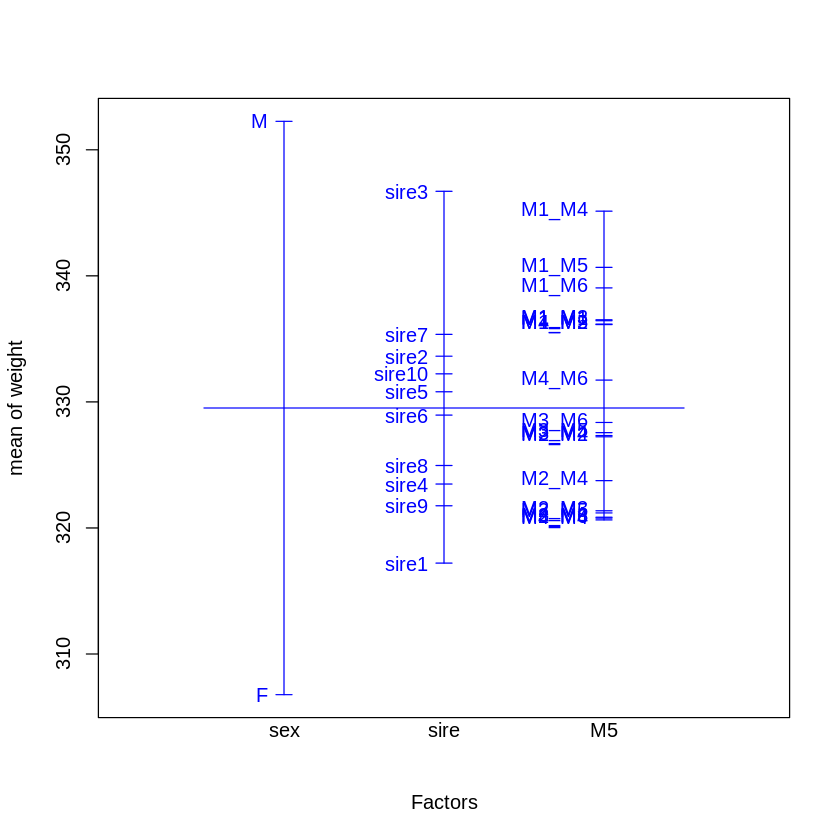

In [ ]:
# Assuming 'markers' is your data frame
markers$sex <- as.factor(markers$sex)  # Convert 'sex' to factor if it's not already
markers$sire <- as.factor(markers$sire) # Convert 'sire' to factor if it's not already
markers$M5 <- as.factor(markers$M5)    # Convert 'M5' to factor if it's not already

# Now try the plot again, excluding 'weight' from the formula:
plot.design(weight ~ sex + sire + M5, data=markers, col="blue")

In [ ]:
#Of course, before we dig into the actual estimates as we did here, the easiest way
#to see if the marker itself has an effect on the trait is with an anova table.
anova(lm(weight~sex+sire+M1,data=markers))

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
sex,1,204821.002,204821.00183,2971.0104118,2.595739e-178
sire,9,21807.084,2423.00938,35.1467186,1.394946e-44
M1,17,958.107,56.35924,0.8175132,6.729177e-01
Residuals,368,25369.864,68.93985,NA,NA


Yes, the only marker worth while looking at is marker 5. A note of caution when
using anova. Terms are tested in the order of the model. Rather crudely this means
that after fitting sex and sire, the marker is tested on the remaining variance not
captured by the first two terms. A bit more formally it is the sequential sums of
squares (SS)—type I; i.e., the improvement in the error SS as an additional term is
added. The order we used here is appropriate and will ensure that the marker does
not “suck up” variation from the other two terms (and we are really only interested
in the marker effects anyhow). If markers were fitted first in the model, they would
all appear to be significant. Keep in mind that the order of terms will change the
results. To get type II errors (hierarchical) or type III (marginal), the Anova function
from the library car can be used. Type III will give the same results as running anova
multiple times with a different order for the factors and only looking at the last level
each time. One point about Anova is that we can test all markers at the same time:

In [ ]:
install.packages("car")
library(car)
Anova(lm(weight~sex+sire+M1+M2+M3+M4+M5,
data=markers), type=3)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘cowplot’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’


Loading required package: carData



,Sum Sq,Df,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),143615.3867,1,5574.5478877,7.876686e-196
sex,162946.6916,1,6324.9081873,1.159367e-203
sire,7529.0336,9,32.4717282,1.595653e-39
M1,335.1287,17,0.7651937,7.328491e-01
M2,293.3923,17,0.6698978,8.319825e-01
M3,346.5625,17,0.7913003,7.031402e-01
M4,573.5369,17,1.3095471,1.844919e-01
M5,14151.2299,17,32.3112637,1.165052e-57
Residuals,7728.8090,300,NA,NA


Results are similar but F-values are slightly lower, which is not surprising given
that more terms were added to the model.
What we did was quite simple. You might want to use a linear mixed effects
model (fixed and random effects)—have a look at lmer in package lme4 or lme in
package nlme. For non linear mixed effects models use nlme also in package nlme.
For generalized linear models glm is a good option. For those familiar with ASReml
there’s an R version—but it’s not free. For binary data use a logistic regression such
as PLR from package MCRestimate or even a simple χ -square test chisq.test.
To end this part let’s compare the results using our linear model with only
fixed effects with a mixed effects model with sire as random.

In [ ]:
library(nlme)
linear=coefficients(lm(weight~sex+sire+M5,
data=markers))[c(1,2,12:28)]
random=fixef(lme(weight~sex+M5,random=~1|sire,
data=markers))
linear=data.frame(effect=names(linear),fixed=linear)
random=data.frame(effect=names(random),random=random)
comparison=merge(linear,random,by="effect")
comparison=data.frame(comparison,
difference=comparison$fixed-comparison$random)
print(comparison)


Attaching package: ‘nlme’


The following object is masked from ‘package:IRanges’:

    collapse




        effect      fixed     random   difference
1  (Intercept) 305.860128 315.115009 -9.254880841
2      M5M1_M2   1.504781   1.490549  0.014232509
3      M5M1_M3   2.328878   2.314576  0.014301890
4      M5M1_M4   3.404947   3.453365 -0.048418026
5      M5M1_M5   1.928433   1.971879 -0.043446586
6      M5M1_M6   2.232493   2.254357 -0.021864058
7      M5M2_M2 -16.270931 -16.370461  0.099530184
8      M5M2_M3 -14.598117 -14.625505  0.027387920
9      M5M2_M4 -14.060934 -14.107196  0.046262575
10     M5M2_M5 -14.298566 -14.344659  0.046093036
11     M5M2_M6 -17.000394 -17.034139  0.033744340
12     M5M3_M3 -14.143775 -14.170504  0.026729166
13     M5M3_M4 -13.574197 -13.602779  0.028581779
14     M5M3_M5 -12.417066 -12.440205  0.023139180
15     M5M3_M6 -14.057730 -14.088632  0.030902255
16     M5M4_M4  -9.443498  -9.441622 -0.001875957
17     M5M4_M5 -12.355493 -12.290890 -0.064603120
18     M5M4_M6 -10.020663 -10.080629  0.059965642
19        sexM  46.151039  46.159111 -0.008071354


The differences are small in this example. In general you might expect smaller
effects with a random model. What we did above was to extract the coefficients
(the ones we wanted to compare—note the use of the index) in linear and the fixed
effects from our random model in random. Then we transformed the results into
data.frames with a column called effect which we used to combine the two (the
function merge can be used to combine data.frames based on the contents of a
column).

In [ ]:
install.packages("RSQLite")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plogr’




In [ ]:
library(RSQLite)

In [ ]:
$sqlite SNPsmall < snpDB.sql

ERROR: Error in parse(text = input): <text>:1:1: unexpected '$'
1: $
    ^


In [ ]:
con=dbConnect(dbDriver("SQLite"),
dbname = "SNPsmall")

Warning message:
“Couldn't set synchronous mode: database disk image is malformed
Use `synchronous` = NULL to turn off this warning.”


In [ ]:
# %%R
# Install rpy2 in your R environment (if not already installed)
if(!requireNamespace("rpy2", quietly = TRUE)) {
  install.packages("rpy2")
 }

# Load the rpy2 library
library(rpy2)

# Now, in a Python cell (not an R cell), use the following to install necessary Python packages:
#!pip install rpy2 # Install the rpy2 package for Python-R interoperability

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘rpy2’ is not available for this version of R

A version of this package for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”


ERROR: Error in library(rpy2): there is no package called ‘rpy2’


In [ ]:
import rpy2.robjects.packages as rpackages

ERROR: Error in parse(text = input): <text>:1:8: unexpected symbol
1: import rpy2.robjects.packages
           ^


In [ ]:


# Import necessary libraries
#import rpy2.robjects as robjects
#from rpy2.robjects.packages import importr

# Import RSQLite library within R
#RSQLite = importr('RSQLite')

# Connect to the database (create if it doesn't exist)
con = RSQLite.dbConnect(RSQLite.dbDriver("SQLite"), dbname="SNPsmall")

# Check if the tables exist. If they exist, drop them.  This is our attempt to fix the error.  Likely, the file is corrupted.
# Removing it and re-writing it is the best option.
#if robjects.r.dbExistsTable(con, "snpmap"):
 #   robjects.r.dbExecute(con, "DROP TABLE snpmap")

#if robjects.r.dbExistsTable(con, "SNP"):
 #   robjects.r.dbExecute(con, "DROP TABLE SNP")

# Write the tables (will create the tables since we dropped them if they existed)
RSQLite.dbWriteTable(con, "snpmap", "SNPmap.txt", header=True, append=True, sep="\t")
RSQLite.dbWriteTable(con, "SNP", "SNPsample.txt", append=True, header=True, skip=9, sep="\t")

# Disconnect from the database
RSQLite.dbDisconnect(con)

ERROR: Error in RSQLite.dbConnect(RSQLite.dbDriver("SQLite"), dbname = "SNPsmall"): could not find function "RSQLite.dbConnect"


In [ ]:
dbWriteTable(con,"snpmap","SNPmap.txt",
header= TRUE, append=T, sep="\t")

ERROR: Error: database disk image is malformed


In [ ]:
dbWriteTable(con,"SNP","SNPsample.txt",
append=T, header=TRUE, skip=9,sep="\t")

In [ ]:
con=dbConnect(dbDriver("SQLite"),
dbname = "SNPsmall")
dbListTables(con)